# Analysing MFs

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import curve_fit
import scipy.special as sp
from astropy.io import fits
import random
from IPython.display import display
from PIL import Image

from helper_tools import *

plt.rcParams.update({
    'text.usetex': True,  
    'font.family': 'serif',  
    'font.serif': ['Times'],
    'font.size': 12,  
    'axes.titlesize': 11,  
    'axes.labelsize': 16,  
    'xtick.labelsize':12,  
    'ytick.labelsize':12,  
    'legend.fontsize':12, 
})

We import the desired mask and downgrade it to $N_{\mathrm{side}} =512$ to match the maps used to calculate the MFs. We will consider [8,10,12]$^\circ$ disks, centered in the pixel centers of a $N_{\mathrm{side}} =8$ map. Additionally, we will only take those discs with at least a given percentage of good pixels (fiducial value will be 50%). 

In [2]:
DISK_RADIUS = 10 #8,12

DISK_PERCENTAGE_REQUIRED = 0.5

SAVEFILE = False
MAKE_PLOTS = False
SAVE_PLOT = False

In [46]:
# SELECT MASK
mask = hp.read_map("./maps/mask/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits").astype(np.bool_) # Last release

# DOWNGRADE MAPS
mask = hp.ud_grade(mask, nside_out=512)
mask_Rdeg = np.zeros(12*8**2,dtype=bool) 
area_Rdeg = np.zeros(12*8**2)
for i in range(12*8**2):  # Over the map
    vec = hp.pix2vec(8, i) #Select point in the 8 map
    ipix_disc = hp.query_disc(nside=512, vec= vec, radius = np.radians(DISK_RADIUS)) #Select disk
    area_Rdeg[i] = np.sum(mask[ipix_disc])/len(ipix_disc)
    if (area_Rdeg[i]>=DISK_PERCENTAGE_REQUIRED): 
        mask_Rdeg[i] = 1

FSKY = np.mean(mask_Rdeg)

##### Visualization of mask effect to $N_{\mathrm{side}} =8$ pixels

<>:1: SyntaxWarning: invalid escape sequence '\%'
<>:1: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_28032/588620426.py:1: SyntaxWarning: invalid escape sequence '\%'
  hp.mollview(mask_Rdeg, title=f"{int(DISK_PERCENTAGE_REQUIRED*100)} \% criteria mask")


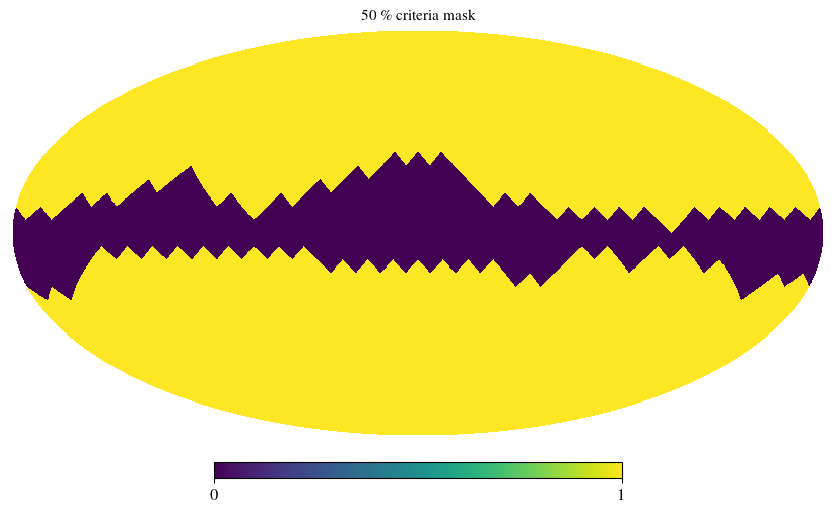

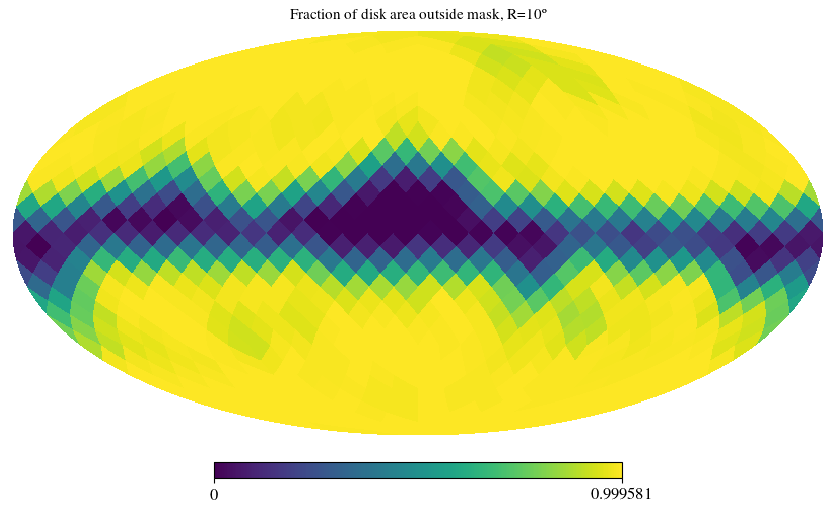

In [4]:
hp.mollview(mask_Rdeg, title=f"{int(DISK_PERCENTAGE_REQUIRED*100)} \% criteria mask")
hp.mollview(area_Rdeg, title=f"Fraction of disk area outside mask, R={DISK_RADIUS}º")

# PART 1 - Calculating $\sigma, \tau$ from V0, V1, V2 maps 

In [5]:
# MF expected value functions
def v0(u, sigma):
    return  1-norm.cdf(u/sigma)

def v1(u, sigma, tau):
    return 1/8*np.exp(-(u/sigma)**2/2)*tau/sigma

def v2(u, sigma, tau):
    return 1/np.sqrt((2*np.pi)**3)*np.exp(-(u/sigma)**2/2)*u*tau**2/sigma**3

In [6]:
# ARRAY OF THRESHOLDS
nside = 8
sigma0 =  68.86260066414593  # Some typical value for the variance of the field
us = np.arange(-sigma0 * 3.5, sigma0 * 3.5, sigma0 * 0.15)
step = us[1] - us[0]
len_us = len(us)

## $\langle V_k(u_i), V_k(u_j)\rangle$ covariance matrix
For each map of the $12\times8^2$ map points, we have V0(u), V1(u), V2(u). Since we have different maps, for each point in the $12\times 8^2$ map we can calculate the variance, and the correlation matrix between points $\langle V_k(u_i), V_k(u_j)\rangle$

In [7]:
# choose a random set of pixels on the sky such that the distance between any two pixels is greater than 20 degrees
def is_valid_pixel(pixel, selected_pixels, min_distance):
    for sp in selected_pixels:
        if hp.rotator.angdist(hp.pix2ang(8,pixel), hp.pix2ang(8,sp)) < min_distance:
            return False
    return True

def select_random_pixels(n, mask, min_distance, try_n=100):
    min_distance = np.deg2rad(min_distance)
    selected_pixels = []
    ite = 0
    while len(selected_pixels) < n and ite < try_n:
        pixel = (random.randint(0, mask.shape[0]-1))
        if mask[pixel] and is_valid_pixel(pixel, selected_pixels, min_distance):
            selected_pixels.append(pixel)
        ite += 1
    return np.array(selected_pixels)

In [8]:
matrix_v0 = []
matrix_v1 = []
matrix_v2 = []
matrix_mapindex = []

if MAKE_PLOTS:
    fig = plt.figure( figsize = (7, 10) )
    gs = fig.add_gridspec(3, hspace=0)
    axs = gs.subplots(sharex=True)
nmaps = 1000
n = 0
for k in range(nmaps):
    if k != 970:
        print(k, end='\r')
        pixel_list = select_random_pixels(100, mask_Rdeg, 2*DISK_RADIUS)
        for i in pixel_list: # We select random pixels (more than 2*R deg apart) to calculate the covariance matrix
            if mask_Rdeg[i]:
                
                matrix_mapindex.append(k)
                n += 1
                hdu0 = fits.open(f'./maps/calculations_new/MF1_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
                hdu1 = fits.open(f'./maps/calculations_new/MF2_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
                hdu2 = fits.open(f'./maps/calculations_new/MF3_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
                v0i = np.array(hdu0[0].data[i])
                v1i = np.array(hdu1[0].data[i])
                v2i = np.array(hdu2[0].data[i])
                hdu0.close()
                hdu1.close()
                hdu2.close()
                if MAKE_PLOTS:
                    axs[0].plot(us, v0i)
                    axs[1].plot(us, v1i)
                    axs[2].plot(us, v2i)
                matrix_v0.append(v0i)
                matrix_v1.append(v1i)
                matrix_v2.append(v2i)

if MAKE_PLOTS:
    axs[0].set_title('Centered MFs')
    axs[0].set_ylabel(r'$v_0$')
    axs[1].set_ylabel(r'$v_1$')
    axs[2].set_ylabel(r'$v_2$')
    axs[2].set_xlabel(r'$u\ / \ \mu K$')
    axs[2].set_ylim(-500, 500)
    plt.show()
cov_matrix_v0 = np.array(matrix_v0)
cov_matrix_v1 = np.array(matrix_v1)
cov_matrix_v2 = np.array(matrix_v2)
cov_matrix_v0 = np.cov(cov_matrix_v0.T)
cov_matrix_v1 = np.cov(cov_matrix_v1.T)
cov_matrix_v2 = np.cov(cov_matrix_v2.T)

hartlap = (n - 47 - 2) / (n - 1)
inv_cov_matrix_v0 = hartlap*np.linalg.inv(cov_matrix_v0)
inv_cov_matrix_v1 = hartlap*np.linalg.inv(cov_matrix_v1)
inv_cov_matrix_v2 = hartlap*np.linalg.inv(cov_matrix_v2)

matrix_mapindex = np.array(matrix_mapindex)

if SAVEFILE:
    np.save(f'./maps/calculations_new/cov_V0_r_{DISK_RADIUS}.npy', cov_matrix_v0)
    np.save(f'./maps/calculations_new/cov_V1_r_{DISK_RADIUS}.npy', cov_matrix_v1)
    np.save(f'./maps/calculations_new/cov_V2_r_{DISK_RADIUS}.npy', cov_matrix_v2)
    np.save(f'./maps/calculations_new/inv_cov_V0_r_{DISK_RADIUS}.npy', inv_cov_matrix_v0)
    np.save(f'./maps/calculations_new/inv_cov_V1_r_{DISK_RADIUS}.npy', inv_cov_matrix_v1)
    np.save(f'./maps/calculations_new/inv_cov_V2_r_{DISK_RADIUS}.npy', inv_cov_matrix_v2)

In [9]:
# PLOT COVARIANCE MATRIX ARRAYS

if MAKE_PLOTS:

    import matplotlib.gridspec as gridspec
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    # Create the figure
    fig = plt.figure(figsize=(8, 7),frameon=False)
    gs = gridspec.GridSpec(2, 4)

    # Create the subplots
    ax1 = fig.add_subplot(gs[0, :2])  # First row, first column
    ax2 = fig.add_subplot(gs[0, 2:])  # First row, second column
    ax3 = fig.add_subplot(gs[1, 1:3], aspect = 'auto') 
    
    axes = [ax1, ax2, ax3]
    titles = [r'$v_0$', r'$v_1$', r'$v_2$']

    # V_0 Matrix and color bar
    im = ax1.imshow(cov_matrix_v0*1e3)
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("left", size="5%", pad=0.4)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.set_title(r"$\times10^{-3}$", fontsize=10, pad=5)
    cax.yaxis.set_ticks_position("left")

    # V_1 Matrix and color bar
    im = ax2.imshow(cov_matrix_v1)
    ax2.set_yticks([])
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)

    # V_2 Matrix and color bar
    im = ax3.imshow(cov_matrix_v2*1e-3)
    divider = make_axes_locatable(ax3)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.set_title(r"$\times10^{3}$", fontsize=10)


    for ax in axes[:2]:
        ax.tick_params(top = True, labeltop = True, bottom = False, labelbottom = False, direction = 'in')
    ax3.tick_params(direction = 'in')


    x = np.linspace(0, 46, 5)
    labels = [f'{x:.0f}' for x in np.linspace(-3.5*sigma0, 3.5*sigma0, 5) ]
    ax1.set_yticks(x, labels)
    ax3.set_yticks(x, labels)
    for i, ax in enumerate(axes):
        ax.set_xticks(x, labels)
        ax.set_xlim(0, 46)
        ax.set_ylim(0, 46)
        ax.set_title(titles[i])
        for spine in ax.spines.values():
            spine.set_visible(False)
            
    plt.subplots_adjust(hspace=0.2, wspace=0.)
    if SAVEFILE:
        plt.savefig(f'./latex/CMB_anomalies_MFs/Figures/Covariance_matrix_r_{DISK_RADIUS}.pdf', bbox_inches='tight')
    plt.show()

## Estimate the local  $\sigma^2$, $\tau^2$ and $\chi^2$ maps for R.3 simulations

#### Estimate $\sigma^2$ and $\chi^2$ from $V_0$ 

In [ ]:
cov_matrix_v0 = np.load(f'./maps/calculations_new/cov_V0_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v0 = np.load(f'./maps/calculations_new/inv_cov_V0_r_{DISK_RADIUS}.npy')
c=0
nmaps = 999

for k in range(nmaps+1):
    if k != 970:
        # Open MF map
        hdu = fits.open(f'./maps/calculations_new/MF1_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
        v0_list = hdu[0].data
        hdu.close()

        # Estimate local $\sigma$ and $\chi^2$
        sigma_map = np.zeros(12*nside**2)
        gof_map = np.zeros(12*nside**2)

        for i in np.arange(12*nside**2)[mask_Rdeg]:
            area = area_Rdeg[i]     
            v0i = v0_list[i]
            c = c+1
            # FIT sigma     
            try:
                popt, pcov = curve_fit(v0, us, v0i, sigma= np.array(cov_matrix_v0/area), p0 = [60]) 
                sigma_map[i] = np.abs(popt[0])
                v = v0i - v0(us, popt[0])
                gof_map[i] = np.dot((v.T).dot(inv_cov_matrix_v0*area), v)
            except:
                print(f'Map {k:05} pixel {i} could not fit curve. Fitting nan instead')
                sigma_map[i] = np.nan
                gof_map[i] = np.nan

        print(f'{c}/{nmaps*np.sum(mask_Rdeg)}', end = '\r')

        if SAVEFILE:
            fits.writeto(f'./maps/calculations_new/sigma2_v0_map_{k:05}_r_{DISK_RADIUS}.fits', sigma_map**2, overwrite=True)
            fits.writeto(f'./maps/calculations_new/gof_v0_map_{k:05}_r_{DISK_RADIUS}.fits', gof_map, overwrite=True)


Map 00010 pixel 253 could not fit curve. Fitting nan instead
Map 00414 pixel 555 could not fit curve. Fitting nan instead


#### Estimate $\sigma²$, $\tau^2$ and $\chi^2$ from $V_1$ 

In [ ]:
cov_matrix_v1 = np.load(f'./maps/calculations_new/cov_V1_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v1 = np.load(f'./maps/calculations_new/inv_cov_V1_r_{DISK_RADIUS}.npy')

list_not_fitted_v1 = []

c = 0
nmaps = 999
for k in np.arange(nmaps+1):
    if k != 970:
        
        hdu = fits.open(f'./maps/calculations_new/MF2_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
        v1_map = hdu[0].data
        hdu.close()
        tau_v1_map = np.zeros(12*nside**2)
        sigma_v1_map = np.zeros(12*nside**2)
        gof_map = np.zeros(12*nside**2)
        for i in np.arange(12*nside**2)[mask_Rdeg]:
            area = area_Rdeg[i]       
            v1i = v1_map[i]
            c = c+1
            try:
                popt, pcov = curve_fit(v1, us,  v1i, sigma= cov_matrix_v1/area,  p0 = [60,3800])
                sigma_v1_map[i] = np.abs(popt[0])
                tau_v1_map[i] = popt[1]
                v = v1i - v1(us, popt[0], popt[1])
                gof_map[i] = np.dot((v.T).dot(inv_cov_matrix_v1*area), v)
            except:
                list_not_fitted_v1.append(f'Map {k:05}, pixel {i}')
                print(f'Map {k:05} pixel {i} could not fit curve. Fitting nan instead')
                sigma_v1_map[i] = np.nan
                tau_v1_map[i] = np.nan
                gof_map[i] = np.nan
        print(f'{c}/{nmaps*np.sum(mask_Rdeg)}', end = '\r')
        
        if SAVEFILE:
            fits.writeto(f'./maps/calculations_new/tau2_v1_map_{k:05}_r_{DISK_RADIUS}.fits', tau_v1_map**2, overwrite=True)
            fits.writeto(f'./maps/calculations_new/sigma2_v1_map_{k:05}_r_{DISK_RADIUS}.fits', sigma_v1_map**2, overwrite=True)
            fits.writeto(f'./maps/calculations_new/gof_v1_map_{k:05}_r_{DISK_RADIUS}.fits', gof_map, overwrite=True)

Map 00270 pixel 242 could not fit curve. Fitting nan instead
Map 00422 pixel 19 could not fit curve. Fitting nan instead
Map 00998 pixel 548 could not fit curve. Fitting nan instead


#### Estimate $\sigma^2$, $\tau^2$ and $\chi^2$ from $V_2$ 

In [ ]:
cov_matrix_v2 = np.load(f'./maps/calculations_new/cov_V2_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v2 = np.load(f'./maps/calculations_new/inv_cov_V2_r_{DISK_RADIUS}.npy')
c = 0
list_not_fitted_v2 = []

for k in np.arange(1000):
    if k != 970:
        hdu = fits.open(f'./maps/calculations_new/MF3_new_mc_{k:05}_r_{DISK_RADIUS}_nside_8.fits')
        v2_map = hdu[0].data
        hdu.close()
        tau_v2_map = np.zeros(12*nside**2)
        sigma_v2_map = np.zeros(12*nside**2)
        gof_map = np.zeros(12*nside**2)
        for i in np.arange(12*nside**2)[mask_Rdeg]:
            area = area_Rdeg[i]
            c = c + 1
            v2i = v2_map[i]
            try:
                popt, pcov = curve_fit(v2, us,  v2i, sigma= np.array(cov_matrix_v2/area), p0 = [60, 3800])
                sigma_v2_map[i] = popt[0]
                tau_v2_map[i] = popt[1]
                v = v2i - v2(us, popt[0], popt[1])
                gof_map[i] = np.dot((v.T).dot(inv_cov_matrix_v2*area), v)
            except:
                list_not_fitted_v2.append(f'Map {k:05}, pixel {i}')
                print(f'Map {k:05} pixel {i} could not fit curve. Fitting nan instead')
                sigma_v2_map[i] = np.nan
                tau_v2_map[i] = np.nan
                gof_map[i] = np.nan
        print(f'{c}/{nmaps*np.sum(mask_Rdeg)}', end = '\r')
        if SAVEFILE:
            fits.writeto(f'./maps/calculations_new/tau2_v2_map_{k:05}_r_{DISK_RADIUS}.fits', tau_v2_map**2, overwrite=True)
            fits.writeto(f'./maps/calculations_new/sigma2_v2_map_{k:05}_r_{DISK_RADIUS}.fits', sigma_v2_map**2, overwrite=True)
            fits.writeto(f'./maps/calculations_new/gof_v2_map_{k:05}_r_{DISK_RADIUS}.fits', gof_map, overwrite=True)


Map 00014 pixel 571 could not fit curve. Fitting nan instead
Map 00181 pixel 603 could not fit curve. Fitting nan instead
Map 00326 pixel 86 could not fit curve. Fitting nan instead
Map 00480 pixel 15 could not fit curve. Fitting nan instead
Map 00594 pixel 681 could not fit curve. Fitting nan instead
Map 00601 pixel 720 could not fit curve. Fitting nan instead
Map 00907 pixel 590 could not fit curve. Fitting nan instead
Map 00947 pixel 729 could not fit curve. Fitting nan instead


## For Planck data

### Estimate the local  $\sigma^2$, $\tau^2$ and $\chi^2$ for Planck data 

In [ ]:
hdu = fits.open(f'./maps/calculations_new/planck_MF1_new_r_{DISK_RADIUS}_nside_8.fits')
planck_v0 = np.array(hdu[0].data)
hdu.close()

hdu = fits.open(f'./maps/calculations_new/planck_MF2_new_r_{DISK_RADIUS}_nside_8.fits')
planck_v1 = np.array(hdu[0].data)
hdu.close()

hdu = fits.open(f'./maps/calculations_new/planck_MF3_new_r_{DISK_RADIUS}_nside_8.fits')
planck_v2 = np.array(hdu[0].data)
hdu.close()

In [ ]:
plank_v0_map_gof = np.zeros(12*nside**2)
plank_v1_map_gof = np.zeros(12*nside**2)
plank_v2_map_gof = np.zeros(12*nside**2)

plank_v0_sigma_map = np.zeros(12*nside**2)
plank_v1_sigma_map = np.zeros(12*nside**2)
plank_v2_sigma_map = np.zeros(12*nside**2)
plank_v1_tau_map = np.zeros(12*nside**2)
plank_v2_tau_map = np.zeros(12*nside**2)

cov_matrix_v0 = np.load(f'./maps/calculations_new/cov_V0_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v0 = np.load(f'./maps/calculations_new/inv_cov_V0_r_{DISK_RADIUS}.npy')
cov_matrix_v1 = np.load(f'./maps/calculations_new/cov_V1_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v1 = np.load(f'./maps/calculations_new/inv_cov_V1_r_{DISK_RADIUS}.npy')
cov_matrix_v2 = np.load(f'./maps/calculations_new/cov_V2_r_{DISK_RADIUS}.npy')
inv_cov_matrix_v2 = np.load(f'./maps/calculations_new/inv_cov_V2_r_{DISK_RADIUS}.npy')


for i in np.arange(12*nside**2)[mask_Rdeg]:

    area = area_Rdeg[i]
    v0i = planck_v0[i]    
    v1i = planck_v1[i]
    v2i = planck_v2[i]
       
    try:
        popt, pcov = curve_fit(v0, us, v0i, sigma= np.array(cov_matrix_v0/area),  p0 = [60])
        plank_v0_sigma_map[i] = popt[0]
        v = v0i - v0(us, popt[0])
        plank_v0_map_gof[i] = np.dot((v.T).dot(inv_cov_matrix_v0*area), v)
    except:
        print(f'Plank data pixel {i} could not fit curve. Fitting nan instead in v0')
        plank_v0_sigma_map[i] = np.nan
        plank_v0_map_gof[i] = np.nan
    
    try:
        popt, pcov = curve_fit(v1, us,  v1i, sigma= np.array(cov_matrix_v1/area),  p0 = [60,3800])
        plank_v1_sigma_map[i] = popt[0]
        plank_v1_tau_map[i] = popt[1]
        v = v1i - v1(us, popt[0], popt[1])
        plank_v1_map_gof[i] = np.dot((v.T).dot(inv_cov_matrix_v1*area), v)
    except:
        print(f'Plank data pixel {i} could not fit curve. Fitting nan instead in v1')
        plank_v1_sigma_map[i] = np.nan
        plank_v1_tau_map[i] = np.nan
        plank_v1_map_gof[i] = np.nan
    
    try:
        popt, pcov = curve_fit(v2, us,  v2i, sigma= np.array(cov_matrix_v2/area), p0 = [60,3800])
        plank_v2_sigma_map[i] = popt[0]
        plank_v2_tau_map[i] = popt[1]
        v = v2i - v2(us, popt[0], popt[1])
        plank_v2_map_gof[i] = np.dot((v.T).dot(inv_cov_matrix_v2*area), v)
    except:
        print(f'Plank data pixel {i} could not fit curve. Fitting nan instead in v2')
        plank_v2_sigma_map[i] = np.nan
        plank_v2_tau_map[i] = np.nan
        plank_v2_map_gof[i] = np.nan

if SAVEFILE:
    fits.writeto(f'./maps/calculations_new/planck_sigma2_v0_map_r_{DISK_RADIUS}.fits', plank_v0_sigma_map**2, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_gof_v0_map_r_{DISK_RADIUS}.fits', plank_v0_map_gof, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_tau2_v1_map_r_{DISK_RADIUS}.fits', plank_v1_tau_map**2, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_sigma2_v1_map_r_{DISK_RADIUS}.fits', plank_v1_sigma_map**2, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_gof_v1_map_r_{DISK_RADIUS}.fits', plank_v1_map_gof, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_tau2_v2_map_r_{DISK_RADIUS}.fits', plank_v2_tau_map**2, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_sigma2_v2_map_r_{DISK_RADIUS}.fits', plank_v2_sigma_map**2, overwrite=True)
    fits.writeto(f'./maps/calculations_new/planck_gof_v2_map_r_{DISK_RADIUS}.fits', plank_v2_map_gof, overwrite=True)

# PART 2 - ANALYSIS OF MAPS

### LOAD PATCH $\sigma^2$ AND PATCH $\tau^2$

In [5]:
patch_sigma2_maps = np.zeros((1000, 12*8**2))
patch_sigma2_maps[970,:] = np.nan
for k in range(1000):
    if k != 970:
        hdu = fits.open(f'./maps/calculations_new/patch_sigma2_{k:05}_r_{DISK_RADIUS}.fits')
        patch_sigma2_maps[k,:] = hdu[0].data
        hdu.close()

patch_tau2_maps = np.zeros((1000, 12*8**2))
patch_tau2_maps[970,:] = np.nan
for k in range(1000):
    if k != 970:
        hdu = fits.open(f'./maps/calculations_new/patch_tau2_{k:05}_r_{DISK_RADIUS}.fits')
        patch_tau2_maps[k,:] = hdu[0].data
        hdu.close()

patch_sigma2_maps[:,~mask_Rdeg] = np.nan
patch_tau2_maps[:,~mask_Rdeg] = np.nan

hdu = fits.open(f'./maps/calculations_new/planck_patch_sigma2_r_{DISK_RADIUS}.fits')
planck_patch_sigma2_map = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_patch_tau2_r_{DISK_RADIUS}.fits')
planck_patch_tau2_map = hdu[0].data
hdu.close()

planck_patch_sigma2_map[~mask_Rdeg] = np.nan
planck_patch_tau2_map[~mask_Rdeg] = np.nan


### Load fitted $\sigma^2$,$\tau^2$ and $\chi^2$ maps 

In [6]:
# Initialise lists
list_sigma2_v0_maps = np.zeros((1000, 12*8**2))
list_sigma2_v1_maps = np.zeros((1000, 12*8**2))
list_sigma2_v2_maps = np.zeros((1000, 12*8**2))
list_tau2_v1_maps = np.zeros((1000, 12*8**2))
list_tau2_v2_maps = np.zeros((1000, 12*8**2))
list_v0_gof = np.zeros((1000, 12*8**2))
list_v1_gof = np.zeros((1000, 12*8**2))
list_v2_gof = np.zeros((1000, 12*8**2))

list_sigma2_v0_maps[970,:] = np.nan
list_sigma2_v1_maps[970,:] = np.nan
list_sigma2_v2_maps[970,:] = np.nan 
list_tau2_v1_maps[970,:] = np.nan
list_tau2_v2_maps[970,:] = np.nan
list_v0_gof[970,:] = np.nan
list_v1_gof[970,:] = np.nan
list_v2_gof[970,:] = np.nan

nmaps = 1000
for k in range(nmaps):
    if k != 970:
        hdu = fits.open(f'./maps/calculations_new/sigma2_v0_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_sigma2_v0_maps[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/gof_v0_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_v0_gof[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/sigma2_v1_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_sigma2_v1_maps[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/tau2_v1_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_tau2_v1_maps[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/gof_v1_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_v1_gof[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/sigma2_v2_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_sigma2_v2_maps[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/tau2_v2_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_tau2_v2_maps[k,:] = hdu[0].data
        hdu.close()
        hdu = fits.open(f'./maps/calculations_new/gof_v2_map_{k:05}_r_{DISK_RADIUS}.fits')
        list_v2_gof[k,:] = hdu[0].data
        hdu.close()

list_sigma2_v0_maps[:,~mask_Rdeg] = np.nan
list_sigma2_v1_maps[:,~mask_Rdeg] = np.nan
list_sigma2_v2_maps[:,~mask_Rdeg] = np.nan
list_tau2_v1_maps[:,~mask_Rdeg] = np.nan
list_tau2_v2_maps[:,~mask_Rdeg] = np.nan
list_v0_gof[:,~mask_Rdeg] = np.nan
list_v1_gof[:,~mask_Rdeg] = np.nan
list_v2_gof[:,~mask_Rdeg] = np.nan

sigma2_threshold = np.nanmax(patch_sigma2_maps)
tau2_threshold = np.nanmax(patch_tau2_maps)
chi2_threshold = 300

v0_mask = (list_sigma2_v0_maps>=sigma2_threshold) + (list_v0_gof>=chi2_threshold)
v1_mask = (list_sigma2_v1_maps>=sigma2_threshold) + (list_tau2_v1_maps>=tau2_threshold) + (list_v1_gof>=chi2_threshold)
v2_mask = (list_sigma2_v2_maps>=sigma2_threshold) + (list_tau2_v2_maps>=tau2_threshold) + (list_v2_gof>=chi2_threshold)

list_sigma2_v0_maps[v0_mask] = np.nan
list_sigma2_v1_maps[v1_mask] = np.nan
list_sigma2_v2_maps[v2_mask] = np.nan

list_tau2_v1_maps[v1_mask] = np.nan
list_tau2_v2_maps[v2_mask] = np.nan

list_v0_gof[v0_mask] = np.nan
list_v1_gof[v1_mask] = np.nan
list_v2_gof[v2_mask] = np.nan
        

hdu = fits.open(f'./maps/calculations_new/planck_sigma2_v0_map_r_{DISK_RADIUS}.fits')
planck_v0_sigma2 = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_gof_v0_map_r_{DISK_RADIUS}.fits')
planck_v0_gof = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_sigma2_v1_map_r_{DISK_RADIUS}.fits')
planck_v1_sigma2 = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_tau2_v1_map_r_{DISK_RADIUS}.fits')
planck_v1_tau2 = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_gof_v1_map_r_{DISK_RADIUS}.fits')
planck_v1_gof = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_sigma2_v2_map_r_{DISK_RADIUS}.fits')
planck_v2_sigma2 = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_tau2_v2_map_r_{DISK_RADIUS}.fits')
planck_v2_tau2 = hdu[0].data
hdu.close()
hdu = fits.open(f'./maps/calculations_new/planck_gof_v2_map_r_{DISK_RADIUS}.fits')
planck_v2_gof = hdu[0].data
hdu.close()


planck_v0_sigma2[~mask_Rdeg] = np.nan
planck_v1_sigma2[~mask_Rdeg] = np.nan
planck_v2_sigma2[~mask_Rdeg] = np.nan
planck_v1_tau2[~mask_Rdeg] = np.nan   
planck_v2_tau2[~mask_Rdeg] = np.nan
planck_v0_gof[~mask_Rdeg] = np.nan
planck_v1_gof[~mask_Rdeg] = np.nan
planck_v2_gof[~mask_Rdeg] = np.nan

### Correlations between different estimators

#### $\sigma^2$ estimators

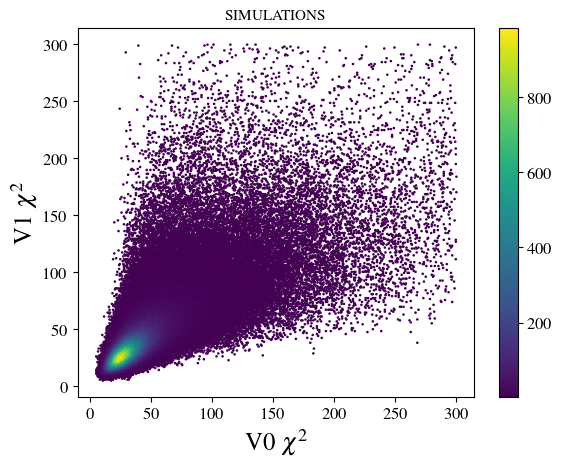

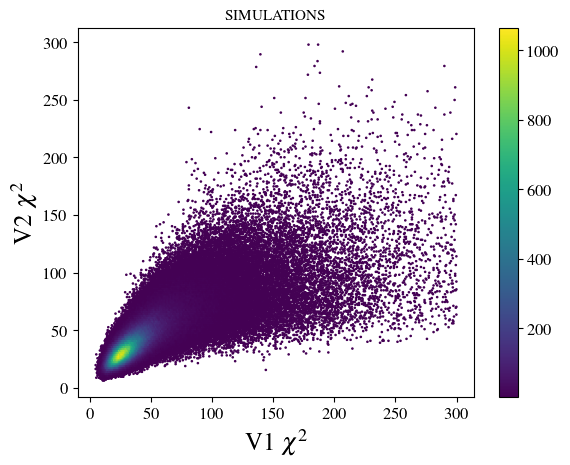

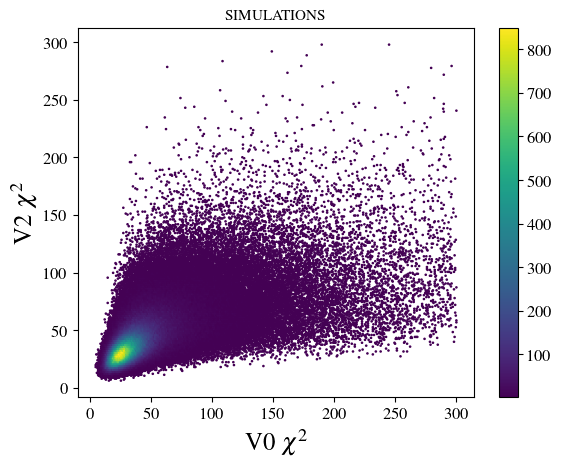

In [7]:
plt.hexbin(list_v0_gof.flatten(), list_v1_gof.flatten(), gridsize=300, cmap="viridis", mincnt=1)
plt.xlabel(r'V0 $\chi^2$',fontsize=18)
plt.ylabel(r'V1 $\chi^2$',fontsize=18)
plt.title('SIMULATIONS')
plt.colorbar()
plt.show()
plt.hexbin(list_v1_gof.flatten(), list_v2_gof.flatten(), gridsize=300, cmap="viridis", mincnt=1)
plt.xlabel(r'V1 $\chi^2$',fontsize=18)
plt.ylabel(r'V2 $\chi^2$',fontsize=18)
plt.title('SIMULATIONS')
plt.colorbar()
plt.show()
plt.hexbin(list_v0_gof.flatten(), list_v2_gof.flatten(), gridsize=300, cmap="viridis", mincnt=1)
plt.xlabel(r'V0 $\chi^2$',fontsize=18)
plt.ylabel(r'V2 $\chi^2$',fontsize=18)
plt.title('SIMULATIONS')
plt.colorbar()
plt.show()

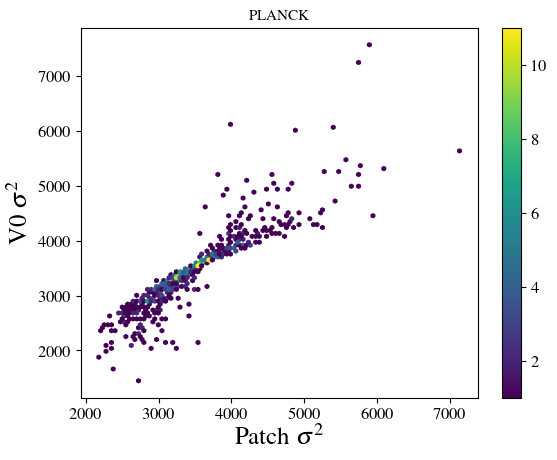

In [8]:
plt.hexbin(planck_patch_sigma2_map.flatten(), planck_v0_sigma2.flatten(), gridsize=100, cmap="viridis", mincnt=1)
plt.xlabel(r'Patch $\sigma^2$',fontsize=18)
plt.ylabel(r'V0 $\sigma^2$',fontsize=18)
plt.title('PLANCK')
plt.colorbar()

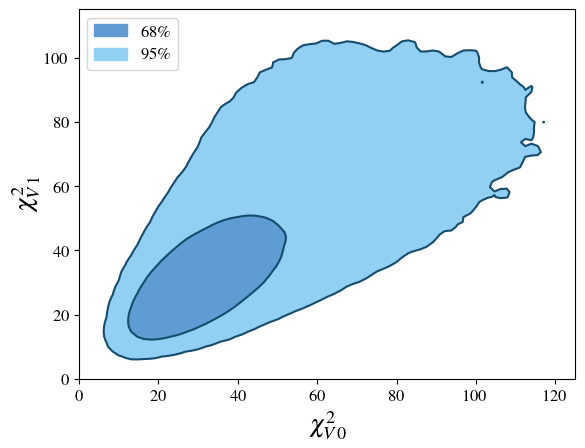

In [9]:
correlation_contour_plot(list_v0_gof,list_v1_gof,liminfs=[0,0],limsups=[125,115],
                         sigma_smoothing=1, xlabel=r'$\chi^2_{V0}$', ylabel=r'$\chi^2_{V1}$')

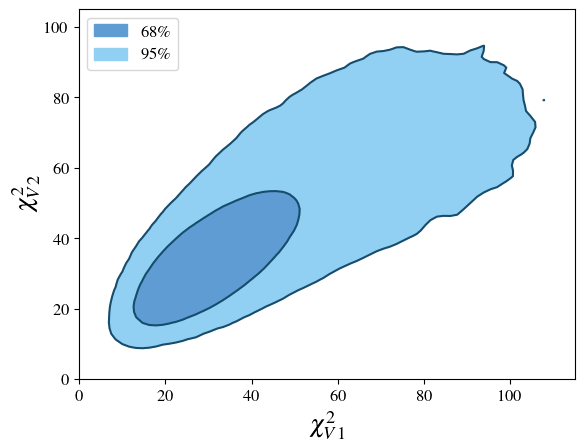

In [10]:
correlation_contour_plot(list_v1_gof,list_v2_gof,liminfs=[0,0],limsups=[115,105],
                         sigma_smoothing=1, xlabel=r'$\chi^2_{V1}$', ylabel=r'$\chi^2_{V2}$')

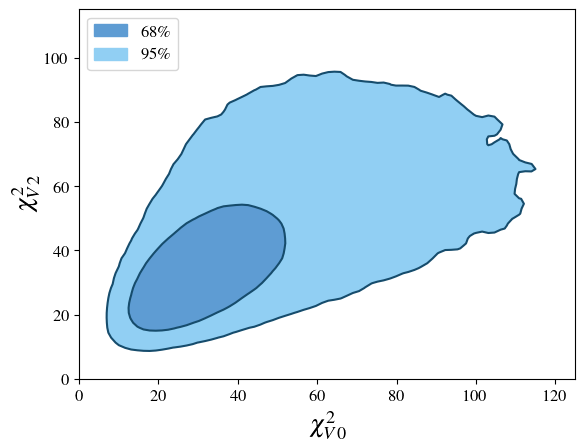

In [11]:
correlation_contour_plot(list_v0_gof,list_v2_gof,liminfs=[0,0],limsups=[125,115],
                         sigma_smoothing=1, xlabel=r'$\chi^2_{V0}$', ylabel=r'$\chi^2_{V2}$')

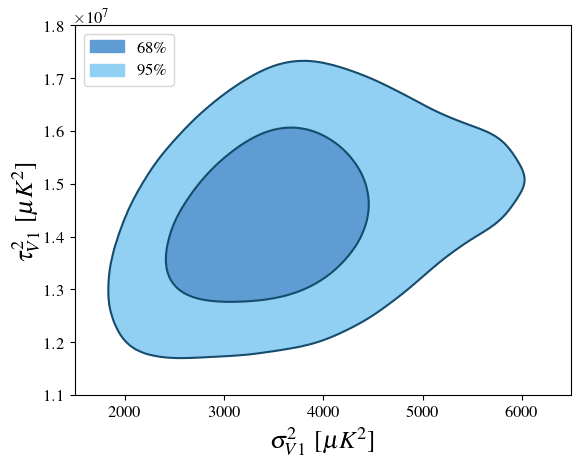

In [12]:
correlation_contour_plot(list_sigma2_v1_maps,list_tau2_v1_maps,liminfs=[1500,1.1e7],limsups=[6500,1.8e7],
                         sigma_smoothing=4, xlabel=r'$\sigma^2_{V1}$ [$\mu K^2$]', ylabel=r'$\tau^2_{V1}$ [$\mu K^2$]')

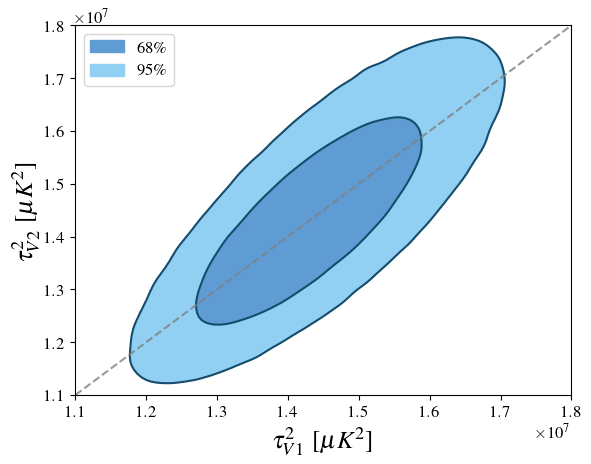

In [13]:
correlation_contour_plot(list_tau2_v1_maps,list_tau2_v2_maps,
                         liminfs=[1.1e7,1.1e7],limsups=[1.8e7,1.8e7],
                         sigma_smoothing=2, xlabel=r'$\tau^2_{V1}$ [$\mu K^2$]', ylabel=r'$\tau^2_{V2}$ [$\mu K^2$]',
                         diag_line=True)

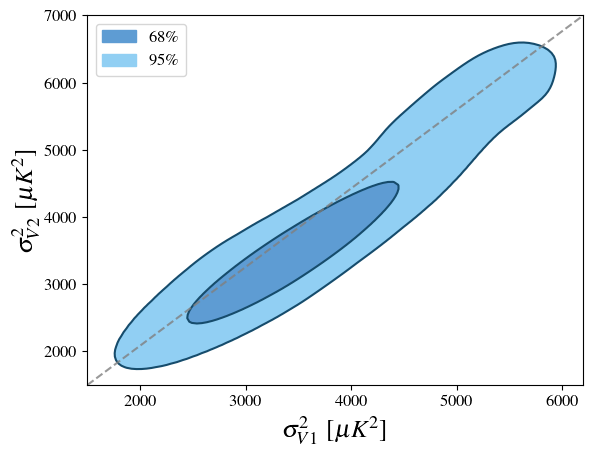

In [14]:
correlation_contour_plot(list_sigma2_v1_maps,list_sigma2_v2_maps,
                         liminfs=[1.5e3,1.5e3],limsups=[6.2e3,7e3],
                         sigma_smoothing=3, xlabel=r'$\sigma^2_{V1}$ [$\mu K^2$]', ylabel=r'$\sigma^2_{V2}$ [$\mu K^2$]',
                         diag_line=True)

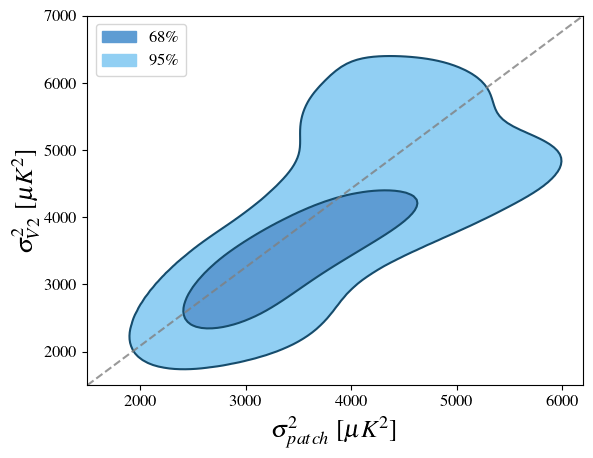

In [15]:
correlation_contour_plot(patch_sigma2_maps,list_sigma2_v2_maps,
                         liminfs=[1.5e3,1.5e3],limsups=[6.2e3,7e3],
                         sigma_smoothing=4, xlabel=r'$\sigma^2_{patch}$ [$\mu K^2$]', ylabel=r'$\sigma^2_{V2}$ [$\mu K^2$]',
                         diag_line=True)

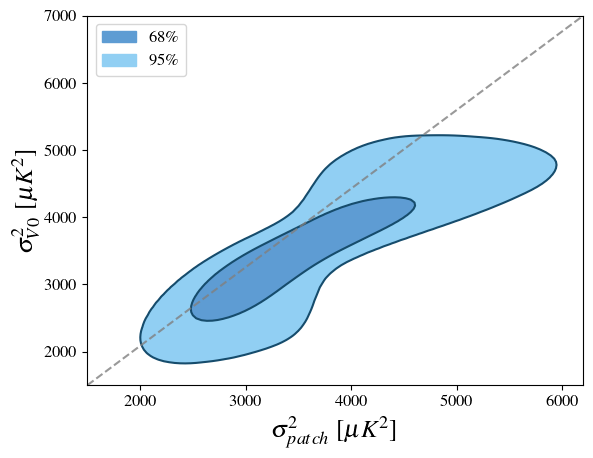

In [16]:
correlation_contour_plot(patch_sigma2_maps,list_sigma2_v0_maps,
                         liminfs=[1.5e3,1.5e3],limsups=[6.2e3,7e3],
                         sigma_smoothing=3, xlabel=r'$\sigma^2_{patch}$ [$\mu K^2$]', ylabel=r'$\sigma^2_{V0}$ [$\mu K^2$]',
                         diag_line=True)

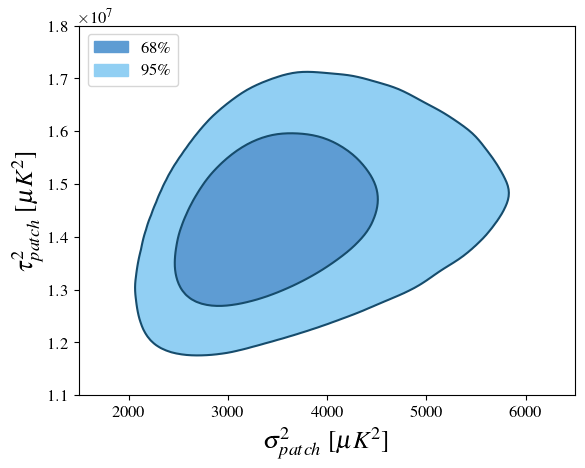

In [17]:
correlation_contour_plot(patch_sigma2_maps,patch_tau2_maps,
                         liminfs=[1500,1.1e7],limsups=[6500,1.8e7],
                         sigma_smoothing=3, xlabel=r'$\sigma^2_{patch}$ [$\mu K^2$]', ylabel=r'$\tau^2_{patch}$ [$\mu K^2$]',
                         diag_line=False)

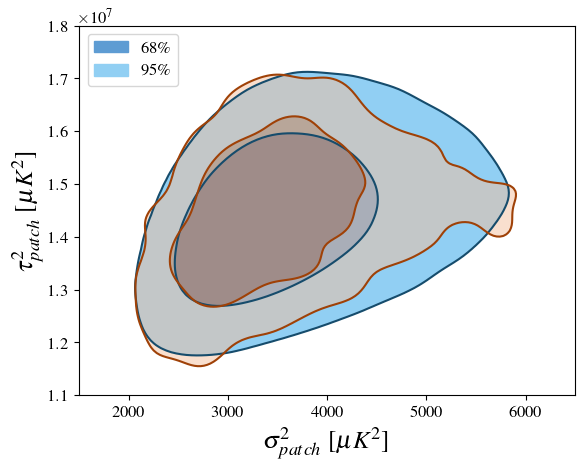

In [18]:
correlation_contour_plot(patch_sigma2_maps,patch_tau2_maps,
                         liminfs=[1500,1.1e7],limsups=[6500,1.8e7],
                         sigma_smoothing=3, xlabel=r'$\sigma^2_{patch}$ [$\mu K^2$]', ylabel=r'$\tau^2_{patch}$ [$\mu K^2$]',
                         diag_line=False)
correlation_contour_plot(planck_patch_sigma2_map,planck_patch_tau2_map,
                         liminfs=[1500,1.1e7],limsups=[6500,1.8e7],
                         sigma_smoothing=6, xlabel=r'$\sigma^2_{patch}$ [$\mu K^2$]', ylabel=r'$\tau^2_{patch}$ [$\mu K^2$]',
                         diag_line=False, Planck=True, alpha=0.5)


#### Studying Some Map Properties

/tmp/ipykernel_28032/639792553.py:1: RuntimeWarning: Mean of empty slice
  hp.mollview(np.nanmean(list_sigma2_v0_maps, axis=0))


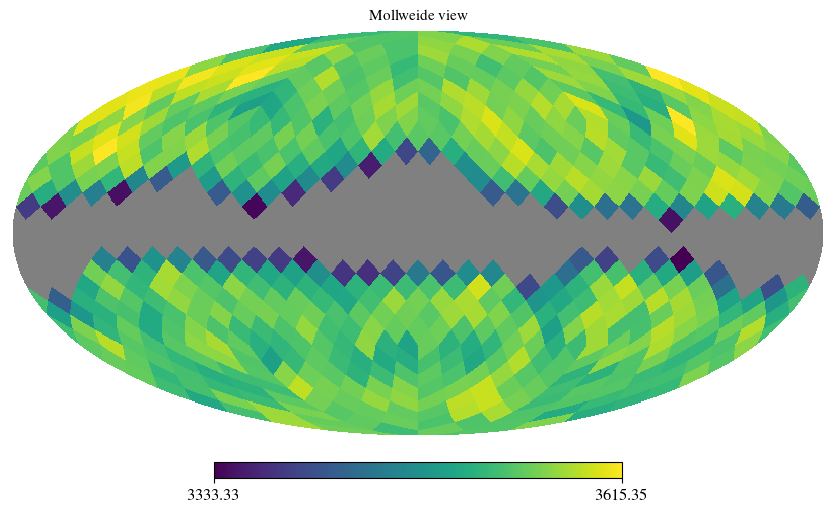

In [19]:
hp.mollview(np.nanmean(list_sigma2_v0_maps, axis=0))

/tmp/ipykernel_28032/419016401.py:1: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v0_gof, axis=0), bins=30,histtype='step',label='V0')
/tmp/ipykernel_28032/419016401.py:2: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v1_gof, axis=0), bins=30,histtype='step',label='V1')
/tmp/ipykernel_28032/419016401.py:3: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v2_gof, axis=0), bins=30,histtype='step',label='V2')


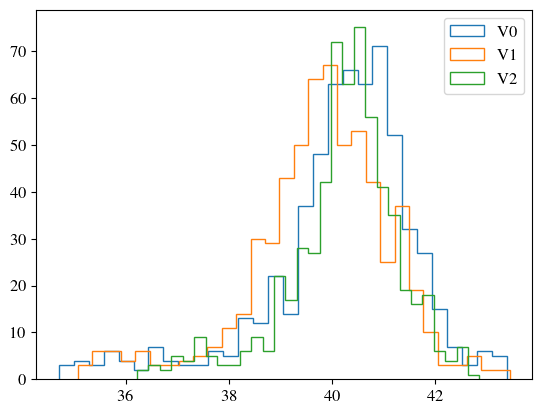

In [20]:
plt.hist(np.nanmean(list_v0_gof, axis=0), bins=30,histtype='step',label='V0')
plt.hist(np.nanmean(list_v1_gof, axis=0), bins=30,histtype='step',label='V1')
plt.hist(np.nanmean(list_v2_gof, axis=0), bins=30,histtype='step',label='V2')
plt.legend()

### Dipole Computation

In [21]:
lmax=10

ClsP_sigma,ClPP_sigma = compute_Cls(patch_sigma2_maps, planck_patch_sigma2_map, lmax=lmax, FSKY=FSKY)
Cls0_sigma,ClP0_sigma = compute_Cls(list_sigma2_v0_maps, planck_v0_sigma2, lmax=lmax, FSKY=FSKY)
Cls1_sigma,ClP1_sigma = compute_Cls(list_sigma2_v1_maps, planck_v1_sigma2, lmax=lmax, FSKY=FSKY)
Cls2_sigma,ClP2_sigma = compute_Cls(list_sigma2_v2_maps, planck_v2_sigma2, lmax=lmax, FSKY=FSKY)

ClsP_tau,ClPP_tau = compute_Cls(patch_tau2_maps, planck_patch_tau2_map, lmax=lmax, FSKY=FSKY)
Cls1_tau,ClP1_tau = compute_Cls(list_tau2_v1_maps, planck_v1_tau2, lmax=lmax, FSKY=FSKY)
Cls2_tau,ClP2_tau = compute_Cls(list_tau2_v2_maps, planck_v2_tau2, lmax=lmax, FSKY=FSKY)

Cls0_gof,ClP0_gof = compute_Cls(list_v0_gof, planck_v0_gof, lmax=lmax, FSKY=FSKY)
Cls1_gof,ClP1_gof = compute_Cls(list_v1_gof, planck_v1_gof, lmax=lmax, FSKY=FSKY)
Cls2_gof,ClP2_gof = compute_Cls(list_v2_gof, planck_v2_gof, lmax=lmax, FSKY=FSKY)


sigmaCls_sim = [ClsP_sigma,Cls0_sigma,Cls1_sigma,Cls2_sigma]
sigmaCls_pl = [ClPP_sigma,ClP0_sigma,ClP1_sigma,ClP2_sigma]

tauCls_sim = [ClsP_tau,Cls1_tau,Cls2_tau]
tauCls_pl = [ClPP_tau,ClP1_tau,ClP2_tau]

gofCls_sim = [Cls0_gof,Cls1_gof,Cls2_gof]
gofCls_pl = [ClP0_gof,ClP1_gof,ClP2_gof]

biglistsims = [ClsP_sigma,Cls0_sigma,Cls1_sigma,Cls2_sigma,ClsP_tau,Cls1_tau,Cls2_tau,Cls0_gof,Cls1_gof,Cls2_gof]
biglistplanck = [ClPP_sigma,ClP0_sigma,ClP1_sigma,ClP2_sigma,ClPP_tau,ClP1_tau,ClP2_tau,ClP0_gof,ClP1_gof,ClP2_gof]

/home/mikel/Desktop/CMB-MFs/helper_tools.py:68: RuntimeWarning: Mean of empty slice
  mean_field = np.nanmean(map_list, axis=0)


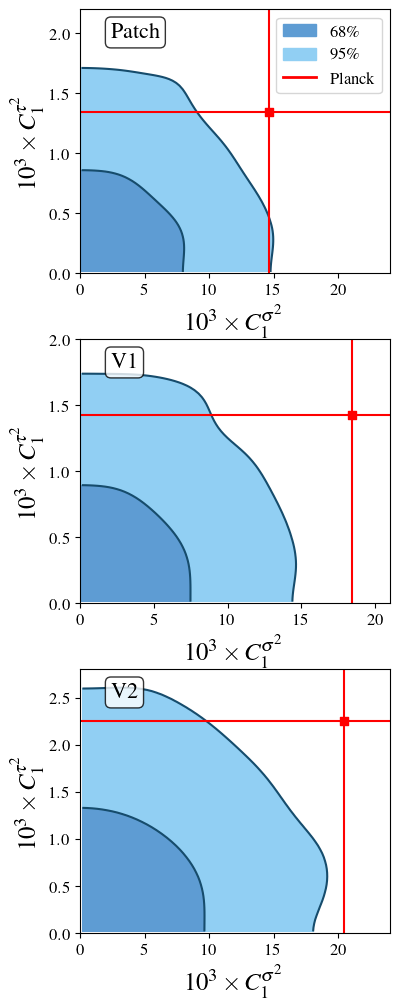

In [22]:
multisigmatau([ClsP_sigma[:,1],Cls1_sigma[:,1],Cls2_sigma[:,1]],
              [ClsP_tau[:,1],Cls1_tau[:,1],Cls2_tau[:,1]],[ClPP_sigma[1],ClP1_sigma[1],ClP2_sigma[1]],
              [ClPP_tau[1],ClP1_tau[1],ClP2_tau[1]],
              my_labels=[r'$10^3\times C_1^{\sigma^2}$', r'$10^3\times C_1^{\tau^2}$'],
              limsups=[[24,2.2],[21,2],[24,2.8]],
              liminfs=[[0,0],[0,0],[0,0]],
              title='')

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dip_amp_corr_sigmatau.pdf', format='pdf', bbox_inches='tight', dpi=300)

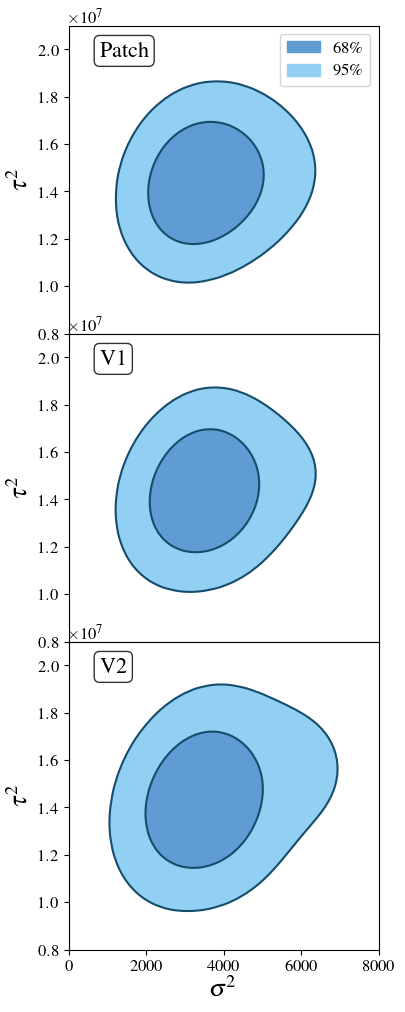

In [23]:
multisigmatau2([patch_sigma2_maps.flatten()/1000,list_sigma2_v1_maps/1000,list_sigma2_v2_maps/1000],
              [patch_tau2_maps.flatten()/1000,list_tau2_v1_maps/1000,list_tau2_v2_maps/1000],
              [0,0,0],
              [0,0,0],
              my_labels=[r'$\sigma^2$', r'$\tau^2$'],
              limsups=[[8000,2.1e7],[8000,2.1e7],[8000,2.1e7]],
              liminfs=[[0,8e6],[0,8e6],[0,8e6]],
              title='',
              turnoff_planck=True)

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/sigmatau_corr_vertical.pdf', format='pdf', bbox_inches='tight', dpi=300)


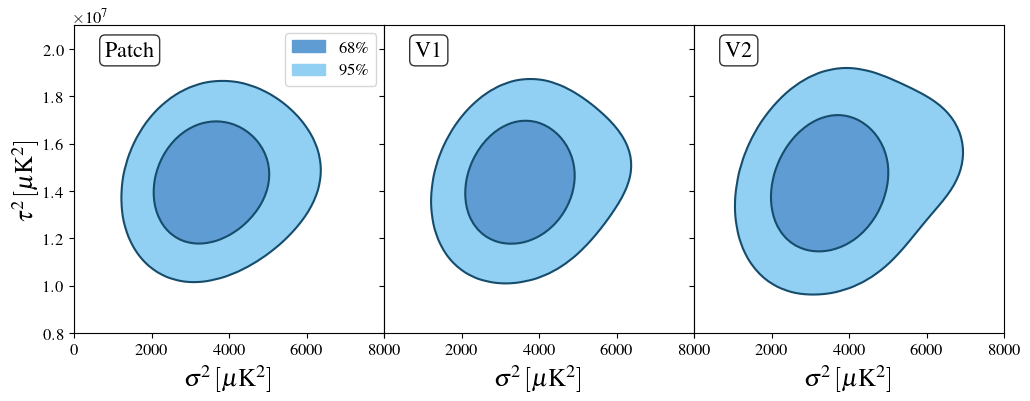

In [24]:
multisigmatau_row([patch_sigma2_maps.flatten()/1000,list_sigma2_v1_maps/1000,list_sigma2_v2_maps/1000],
              [patch_tau2_maps.flatten()/1000,list_tau2_v1_maps/1000,list_tau2_v2_maps/1000],
              [0,0,0],
              [0,0,0],
              my_labels=[r'$\sigma^2 \,[\rm{\mu K^2}]$', r'$\tau^2 \,[\rm{\mu K^2}]$'],
              limsups=[[8000,2.1e7],[8000,2.1e7],[8000,2.1e7]],
              liminfs=[[0,8e6],[0,8e6],[0,8e6]],
              title='',
              turnoff_planck=True)

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/sigmatau_corr_horizontal.pdf', format='pdf', bbox_inches='tight', dpi=300)


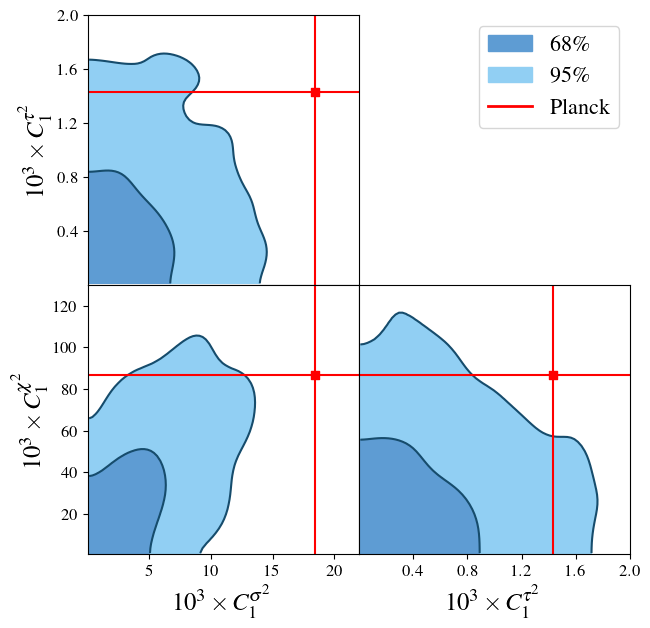

In [25]:
multiamplitude(Cls1_sigma[:,1],Cls1_tau[:,1],Cls1_gof[:,1],ClP1_sigma[1],ClP1_tau[1],ClP1_gof[1],title=r'',
               #my_labels=[r'$10^3\times C_1^{\sigma^2, V_1}$', r'$10^3\times C_1^{\tau^2, V_1}$', r'$10^3\times C_1^{\chi^2, V_1}$'],
               my_labels=[r'$10^3\times C_1^{\sigma^2}$', r'$10^3\times C_1^{\tau^2}$', r'$10^3\times C_1^{\chi^2}$'],
               limsups=[[22,2],[22,130],[2,130]])

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dip_amp_corr_V1.pdf', format='pdf', bbox_inches='tight', dpi=300)


(<Figure size 2400x2400 with 100 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$10^3\\times C_1$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Ax

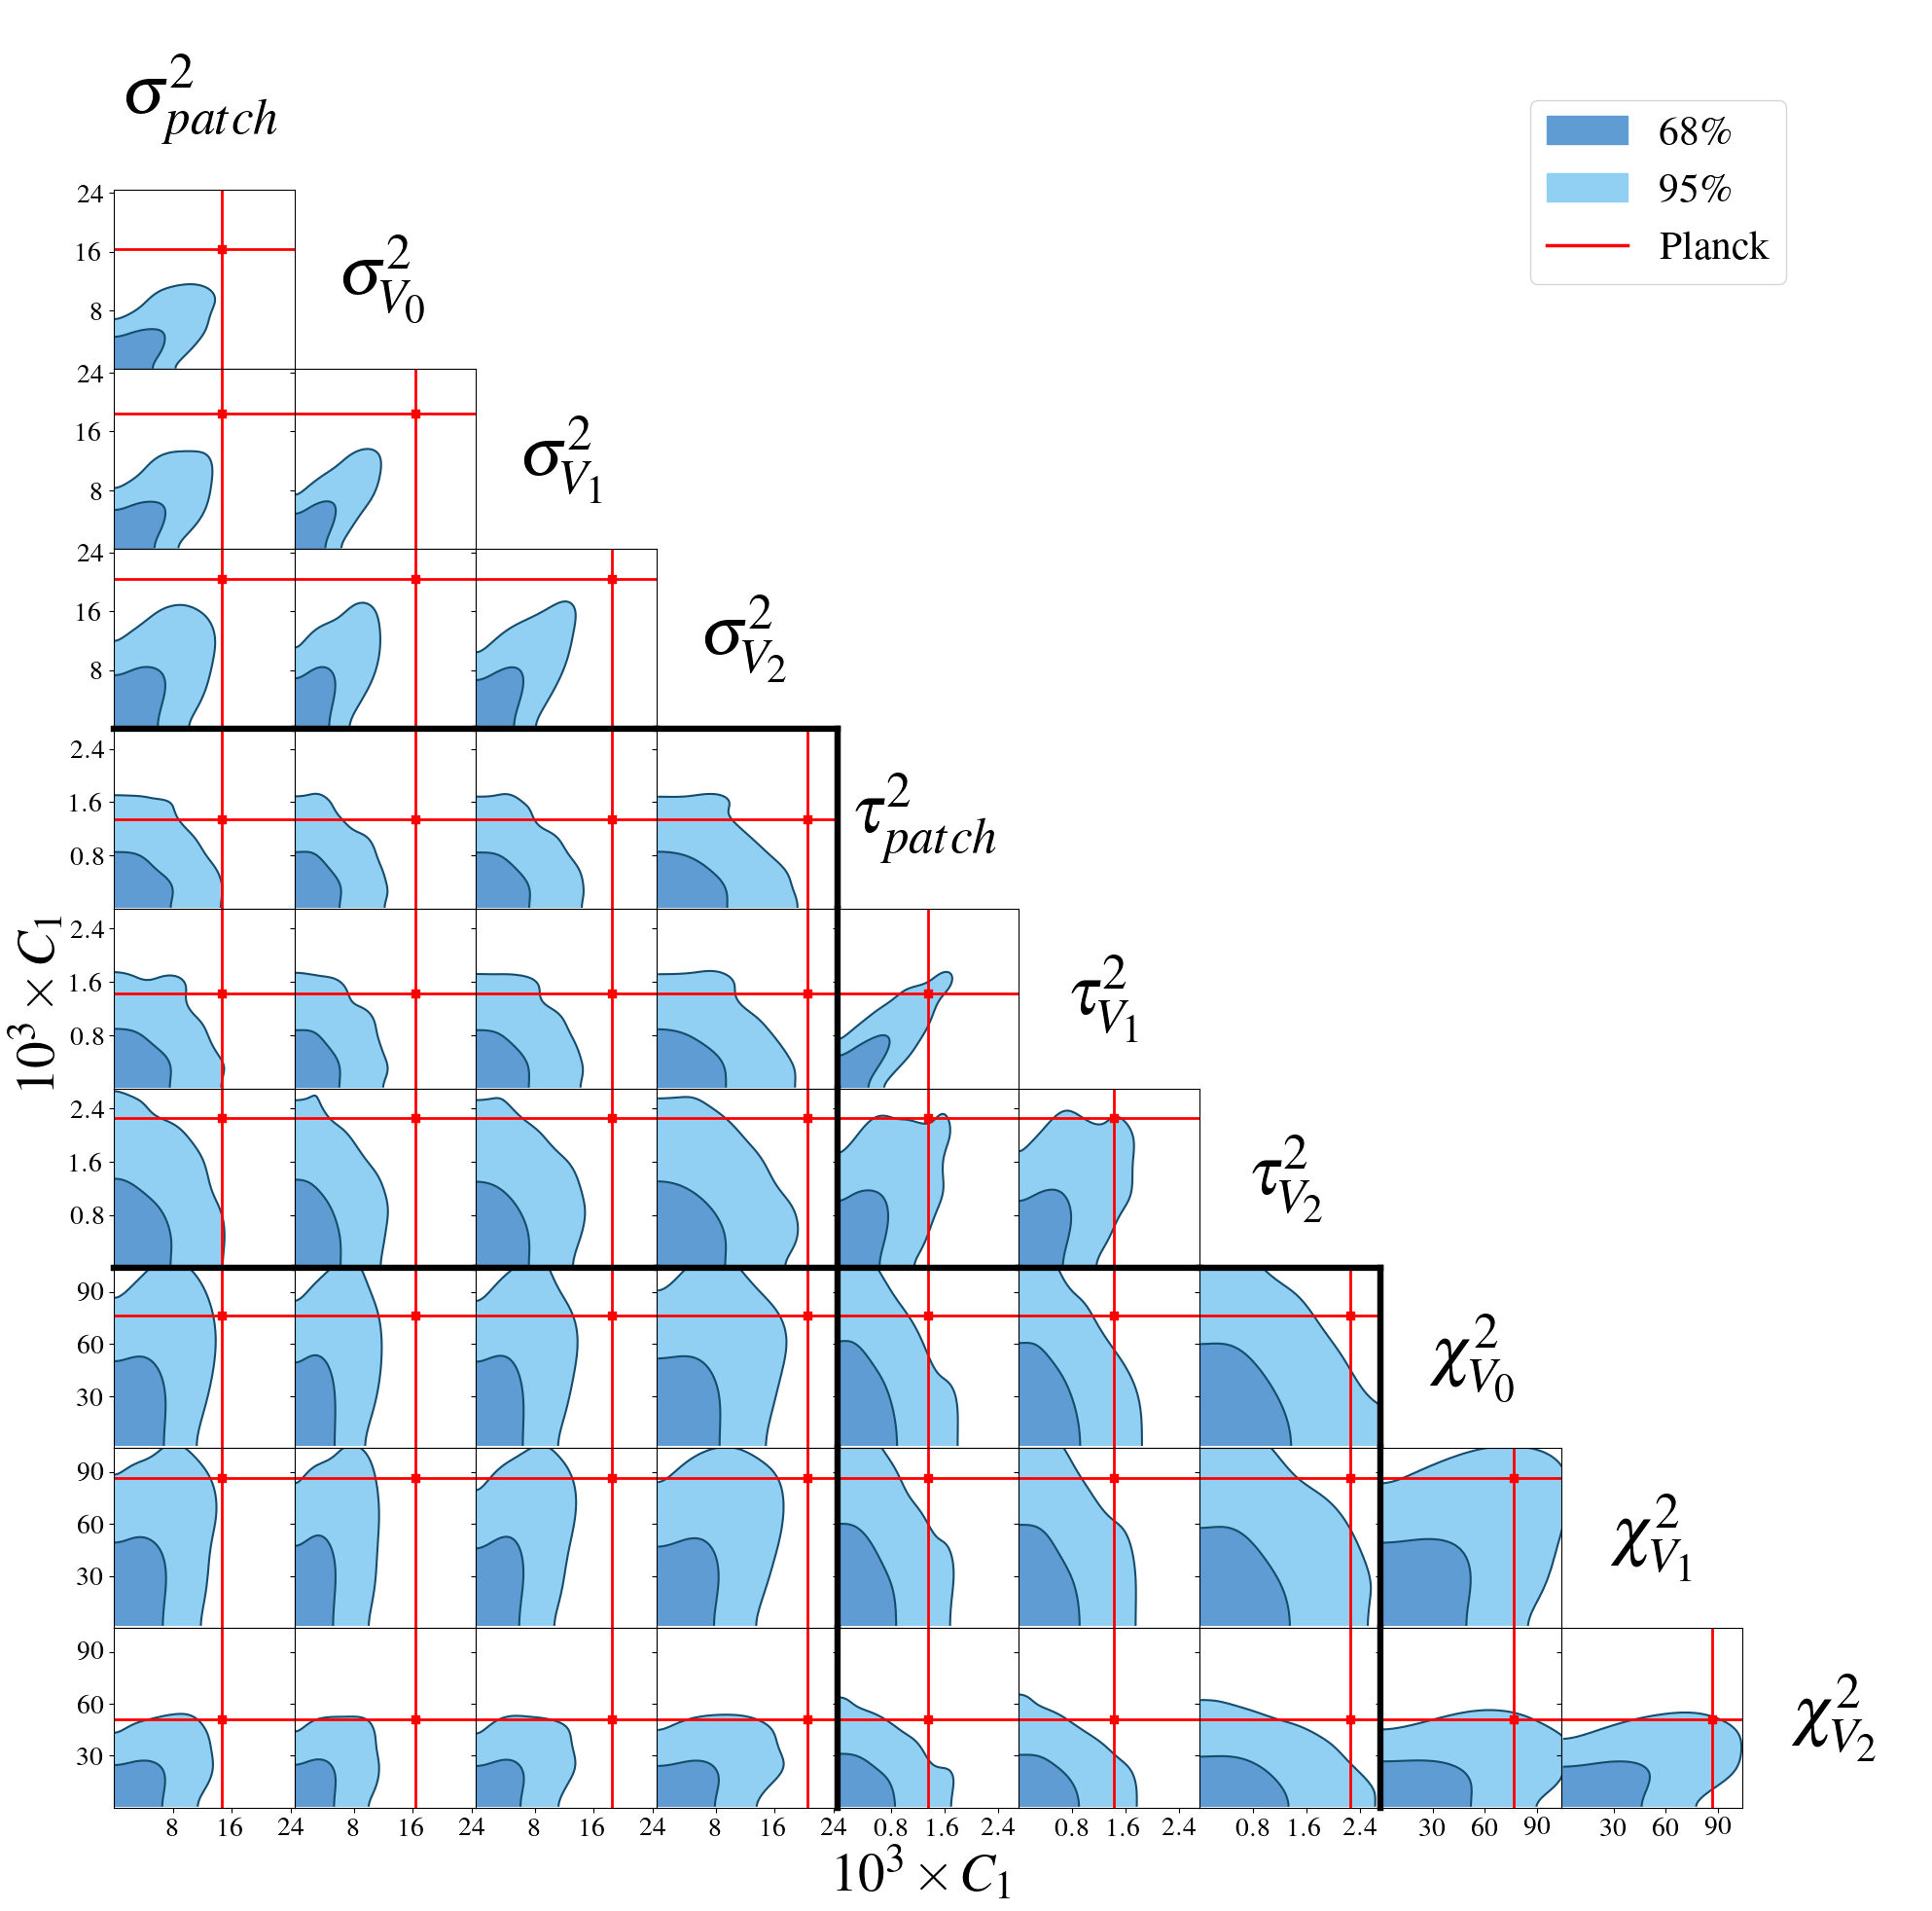

In [26]:
new_corner_contour_plot(np.array(biglistsims)[:,:,1],np.array(biglistplanck)[:,1],
                my_labels = [r'$\sigma^2_{patch}$', r'$\sigma^2_{V_0}$',r'$\sigma^2_{V_1}$',r'$\sigma^2_{V_2}$',
                r'$\tau^2_{patch}$',r'$\tau^2_{V_1}$',r'$\tau^2_{V_2}$',
                r'$\chi^2_{V_0}$',r'$\chi^2_{V_1}$',r'$\chi^2_{V_2}$'],
                title='',
                group_sizes=[4,3,3])

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/massive_dipamp_cornerplot.pdf', format='pdf', bbox_inches='tight', dpi=300)


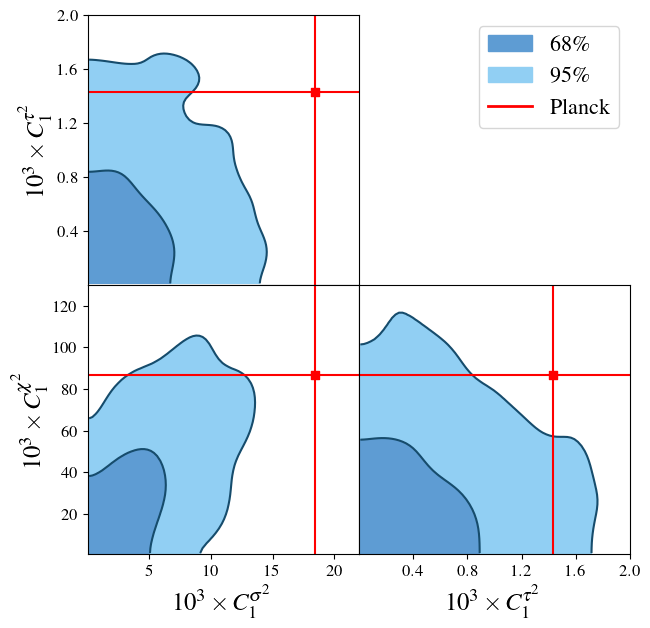

In [27]:
multiamplitude(Cls1_sigma[:,1],Cls1_tau[:,1],Cls1_gof[:,1],ClP1_sigma[1],ClP1_tau[1],ClP1_gof[1],title=r'',
               #my_labels=[r'$10^3\times C_1^{\sigma^2, V_1}$', r'$10^3\times C_1^{\tau^2, V_1}$', r'$10^3\times C_1^{\chi^2, V_1}$'],
               my_labels=[r'$10^3\times C_1^{\sigma^2}$', r'$10^3\times C_1^{\tau^2}$', r'$10^3\times C_1^{\chi^2}$'],
               limsups=[[22,2],[22,130],[2,130]])

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dip_amp_corr_V1.pdf', format='pdf', bbox_inches='tight', dpi=300)


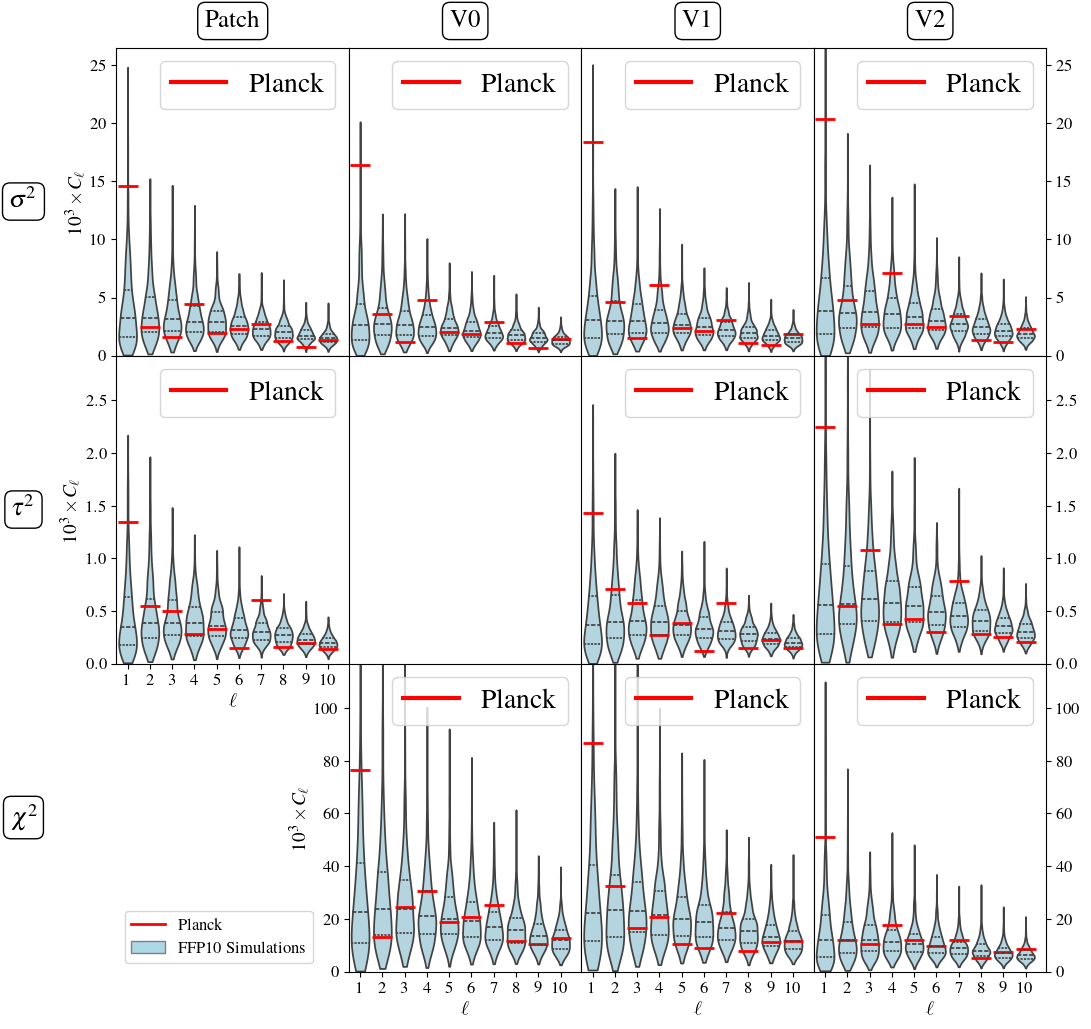

In [28]:
bigmultiviolinplot(biglistsims,biglistplanck)
#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/higher_multipoles_big.pdf', format='pdf', bbox_inches='tight', dpi=300)


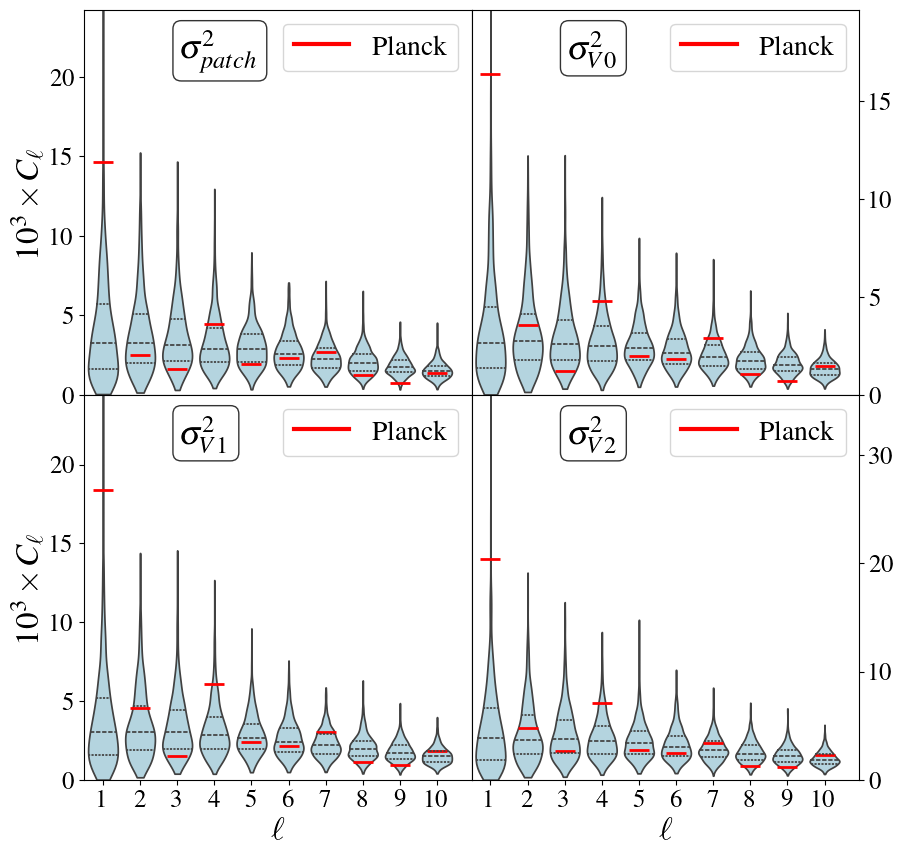

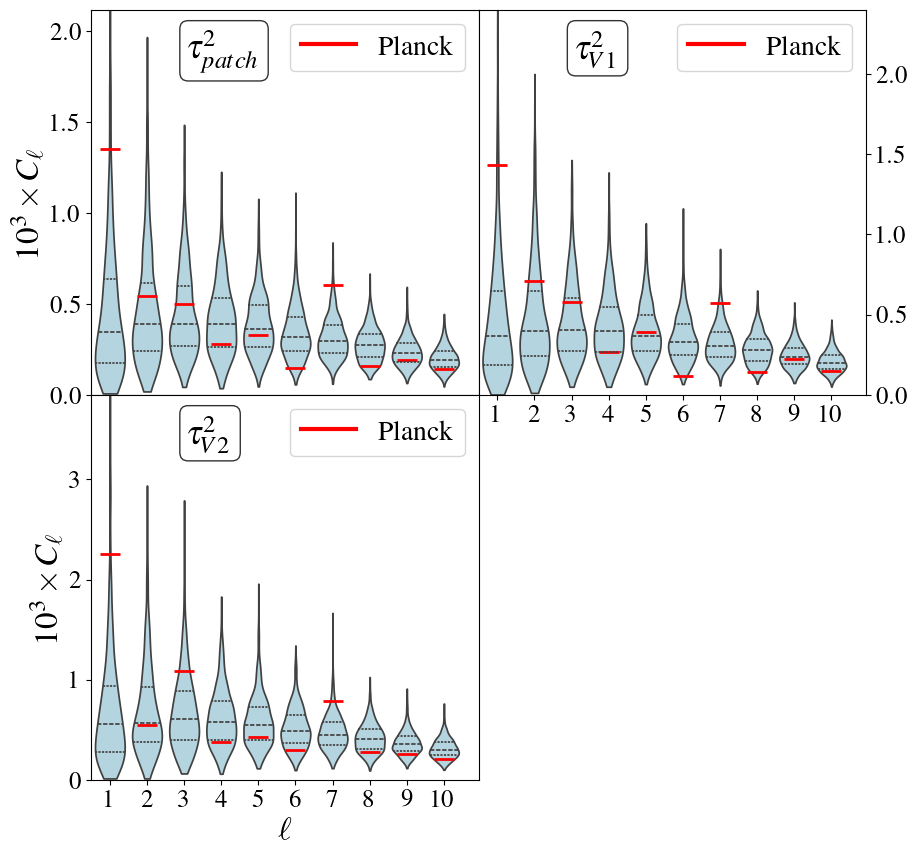

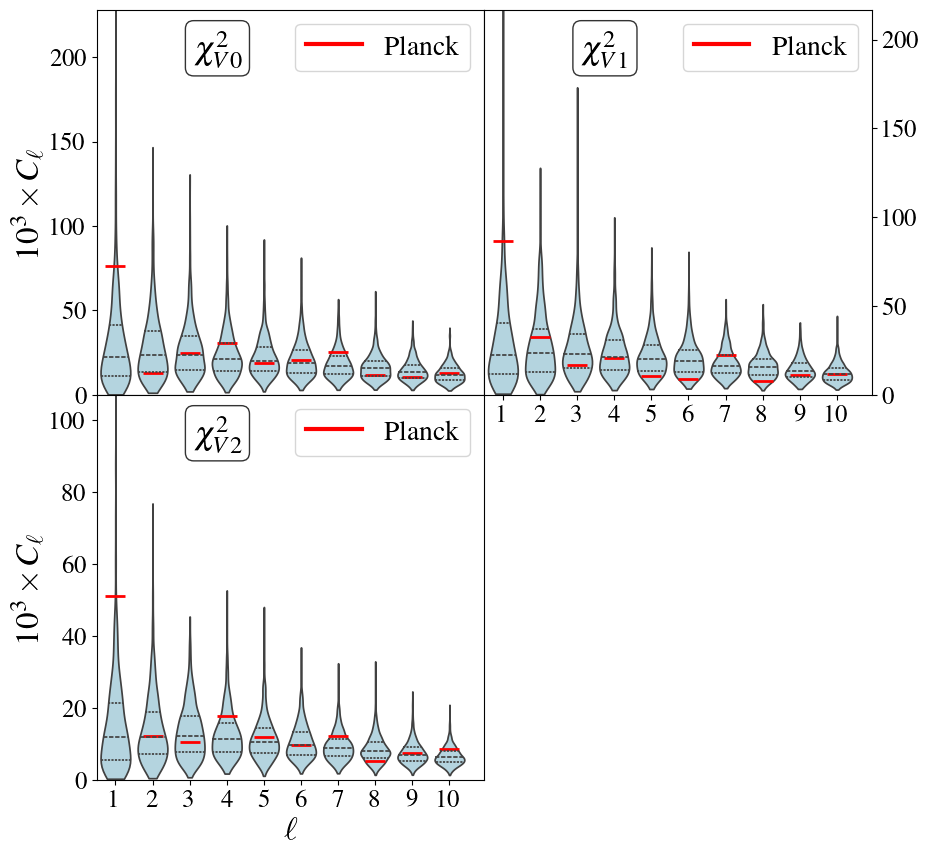

In [29]:
multiviolinplot(sigmaCls_sim,sigmaCls_pl,tag="sigma")
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/violin_sigma.pdf', format='pdf', bbox_inches='tight', dpi=300)
multiviolinplot(tauCls_sim,tauCls_pl,tag="tau")
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/violin_tau.pdf', format='pdf', bbox_inches='tight', dpi=300)
multiviolinplot(gofCls_sim,gofCls_pl,tag="gof")
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/violin_gof.pdf', format='pdf', bbox_inches='tight', dpi=300)



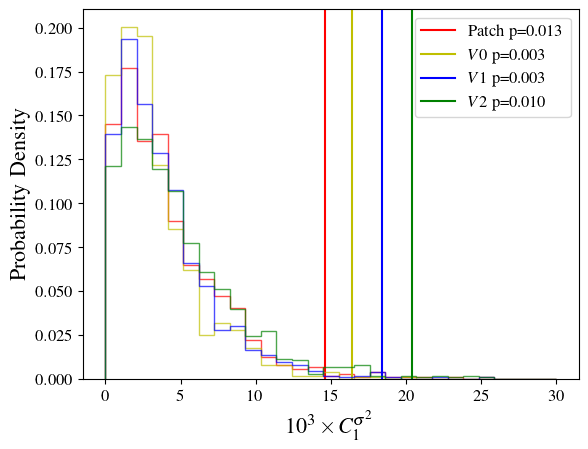

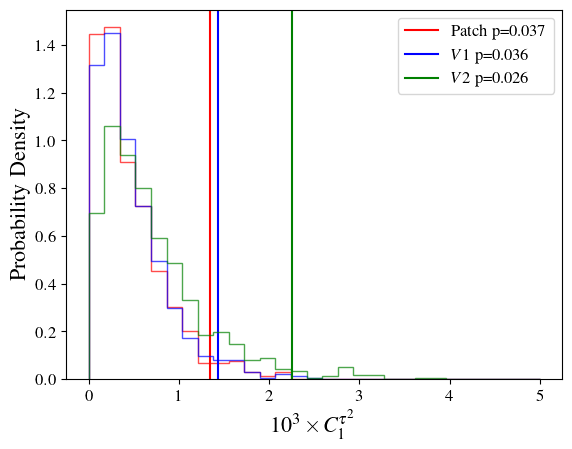

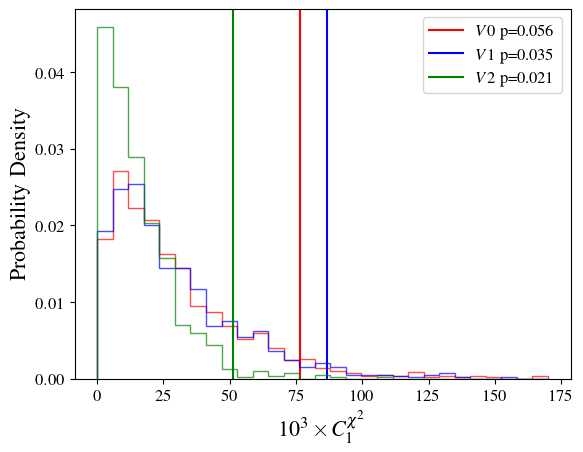

In [30]:
numbins=30

bins_sigma = np.linspace(0,30,numbins)
bins_tau = np.linspace(0,5,numbins)
bins_gof = np.linspace(0,170,numbins)

plot_dipole_histogram(ClsP_sigma[:,1],ClPP_sigma[1],color='r',label=r'Patch',bins=bins_sigma)
plot_dipole_histogram(Cls0_sigma[:,1],ClP0_sigma[1],color='y',label=r'$V0$',bins=bins_sigma)
plot_dipole_histogram(Cls1_sigma[:,1],ClP1_sigma[1],color='b',label=r'$V1$',bins=bins_sigma)
plot_dipole_histogram(Cls2_sigma[:,1],ClP2_sigma[1],color='g',label=r'$V2$',bins=bins_sigma,tag='sigma')
#plt.title(r'$\sigma^2$, DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/diphist_sigma.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

plot_dipole_histogram(ClsP_tau[:,1],ClPP_tau[1],color='r',label=r'Patch',bins=bins_tau)
plot_dipole_histogram(Cls1_tau[:,1],ClP1_tau[1],color='b',label=r'$V1$',bins=bins_tau)
plot_dipole_histogram(Cls2_tau[:,1],ClP2_tau[1],color='g',label=r'$V2$',bins=bins_tau,tag='tau')
#plt.title(r'$\tau^2$, DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/diphist_tau.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

plot_dipole_histogram(Cls0_gof[:,1],ClP0_gof[1],color='r',label=r'$V0$',bins=bins_gof)
plot_dipole_histogram(Cls1_gof[:,1],ClP1_gof[1],color='b',label=r'$V1$',bins=bins_gof)
plot_dipole_histogram(Cls2_gof[:,1],ClP2_gof[1],color='g',label=r'$V2$',bins=bins_gof,tag='gof')
#plt.title(r'$\chi^2$, DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/diphist_gof.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

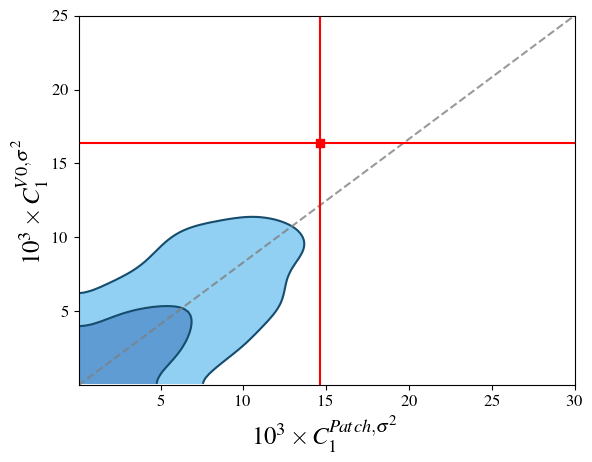

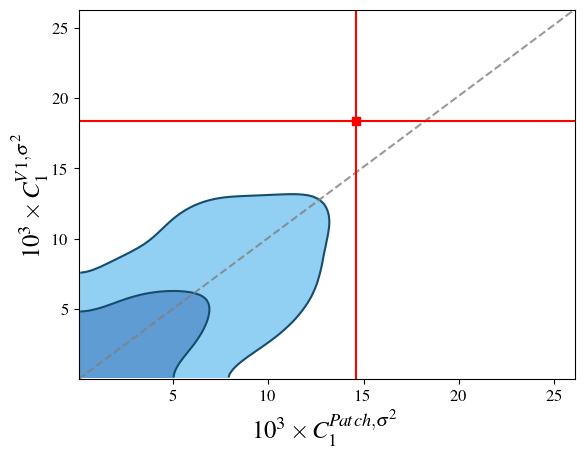

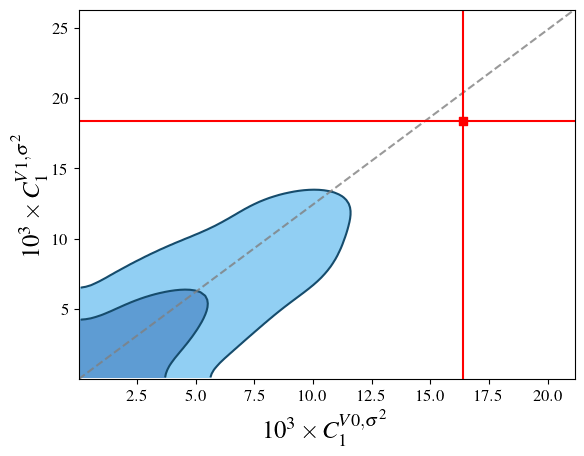

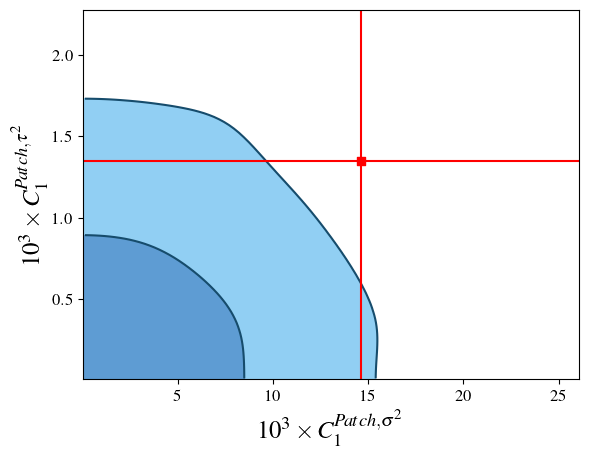

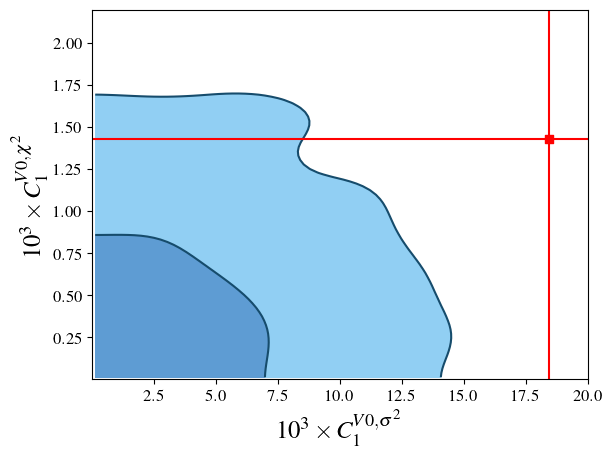

In [31]:
dipole_contour_plot(plt.gca(), ClsP_sigma[:,1], Cls0_sigma[:,1], [ClPP_sigma[1], ClP0_sigma[1]],
                    xlabel=r'$10^3\times C_1^{Patch,\sigma^2}$', ylabel=r'$10^3\times C_1^{V0,\sigma^2}$',
                    limsups=[30,25],
                    sigma_smoothing=6,
                    diag_line=True)
#plt.title('DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dipcorr_sigma_pV0.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

dipole_contour_plot(plt.gca(), ClsP_sigma[:,1], Cls1_sigma[:,1], [ClPP_sigma[1], ClP1_sigma[1]],
                    xlabel=r'$10^3\times C_1^{Patch,\sigma^2}$', ylabel=r'$10^3\times C_1^{V1,\sigma^2}$',
                    sigma_smoothing=6,
                    diag_line=True)
#plt.title('DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
plt.show()

dipole_contour_plot(plt.gca(), Cls0_sigma[:,1], Cls1_sigma[:,1], [ClP0_sigma[1], ClP1_sigma[1]],
                    xlabel=r'$10^3\times C_1^{V0,\sigma^2}$', ylabel=r'$10^3\times C_1^{V1,\sigma^2}$',
                    sigma_smoothing=6,
                    diag_line=True)
#plt.title('DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
plt.show()

dipole_contour_plot(plt.gca(), ClsP_sigma[:,1], ClsP_tau[:,1], [ClPP_sigma[1], ClPP_tau[1]],
                    xlabel=r'$10^3\times C_1^{Patch,\sigma^2}$', ylabel=r'$10^3\times C_1^{Patch,\tau^2}$',
                    sigma_smoothing=10,
                    diag_line=False)
#plt.title('DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
plt.show()

dipole_contour_plot(plt.gca(), Cls1_sigma[:,1], Cls1_tau[:,1], [ClP1_sigma[1], ClP1_tau[1]],
                    xlabel=r'$10^3\times C_1^{V0,\sigma^2}$', ylabel=r'$10^3\times C_1^{V0,\chi^2}$',
                    limsups=[20,2.2],
                    sigma_smoothing=6,
                    diag_line=False)
#plt.title('DiskReq: '+str(DISK_PERCENTAGE_REQUIRED),fontsize=18)
plt.show()

/tmp/ipykernel_28032/1997934817.py:1: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v0_gof, axis=0), bins=20,histtype='step',label='V0')
/tmp/ipykernel_28032/1997934817.py:2: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v1_gof, axis=0), bins=20,histtype='step',label='V1')
/tmp/ipykernel_28032/1997934817.py:3: RuntimeWarning: Mean of empty slice
  plt.hist(np.nanmean(list_v2_gof, axis=0), bins=20,histtype='step',label='V2')


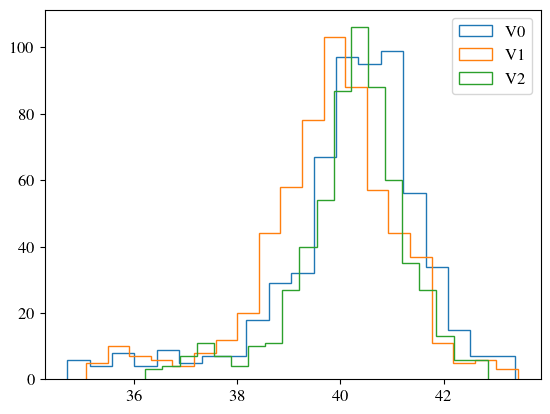

In [32]:
plt.hist(np.nanmean(list_v0_gof, axis=0), bins=20,histtype='step',label='V0')
plt.hist(np.nanmean(list_v1_gof, axis=0), bins=20,histtype='step',label='V1')
plt.hist(np.nanmean(list_v2_gof, axis=0), bins=20,histtype='step',label='V2')
plt.legend()

40.20205676159723


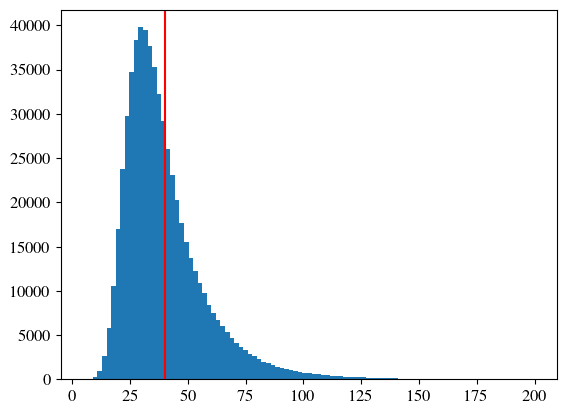

In [33]:
mean = np.nanmean(list_v2_gof)
good_v0_gof = np.nan_to_num(list_v2_gof)
plt.hist(good_v0_gof.flatten(),bins=np.linspace(5,200,num=100))
plt.axvline(mean, color='red', label='Mean')
print(mean)

### Direction Analysis

In [34]:
dips_sigma_patch, dip_planck_sigma_patch = extract_dipole_dirs(patch_sigma2_maps, planck_patch_sigma2_map)
dips_tau_patch, dip_planck_tau_patch = extract_dipole_dirs(patch_tau2_maps, planck_patch_tau2_map)

dips_sigma_V0, dip_planck_sigma_V0 = extract_dipole_dirs(list_sigma2_v0_maps, planck_v0_sigma2)
dips_sigma_V1, dip_planck_sigma_V1 = extract_dipole_dirs(list_sigma2_v1_maps, planck_v1_sigma2)
dips_sigma_V2, dip_planck_sigma_V2 = extract_dipole_dirs(list_sigma2_v2_maps, planck_v2_sigma2)

dips_tau_V1, dip_planck_tau_V1 = extract_dipole_dirs(list_tau2_v1_maps, planck_v1_tau2)
dips_tau_V2, dip_planck_tau_V2 = extract_dipole_dirs(list_tau2_v2_maps, planck_v2_tau2)

dips_gof_V0, dip_planck_gof_V0 = extract_dipole_dirs(list_v0_gof,planck_v0_gof)
dips_gof_V1, dip_planck_gof_V1 = extract_dipole_dirs(list_v1_gof,planck_v1_gof)
dips_gof_V2, dip_planck_gof_V2 = extract_dipole_dirs(list_v2_gof,planck_v2_gof)

sim_dips = [dips_sigma_patch, dips_sigma_V0, dips_sigma_V1, dips_sigma_V2,
                dips_tau_patch, dips_tau_V1, dips_tau_V2,
                dips_gof_V0, dips_gof_V1, dips_gof_V2]

planck_dips = [dip_planck_sigma_patch, dip_planck_sigma_V0, dip_planck_sigma_V1, dip_planck_sigma_V2,
                dip_planck_tau_patch, dip_planck_tau_V1, dip_planck_tau_V2,
                dip_planck_gof_V0, dip_planck_gof_V1, dip_planck_gof_V2]

dip_labels = [r'$\sigma^2_{patch}$', r'$\sigma^2_{V_0}$',r'$\sigma^2_{V_1}$',r'$\sigma^2_{V_2}$',
                r'$\tau^2_{patch}$',r'$\tau^2_{V_1}$',r'$\tau^2_{V_2}$',
                r'$\chi^2_{V_0}$',r'$\chi^2_{V_1}$',r'$\chi^2_{V_2}$']

/home/mikel/Desktop/CMB-MFs/helper_tools.py:678: RuntimeWarning: Mean of empty slice
  mean_field = np.nanmean(map_list, axis=0)


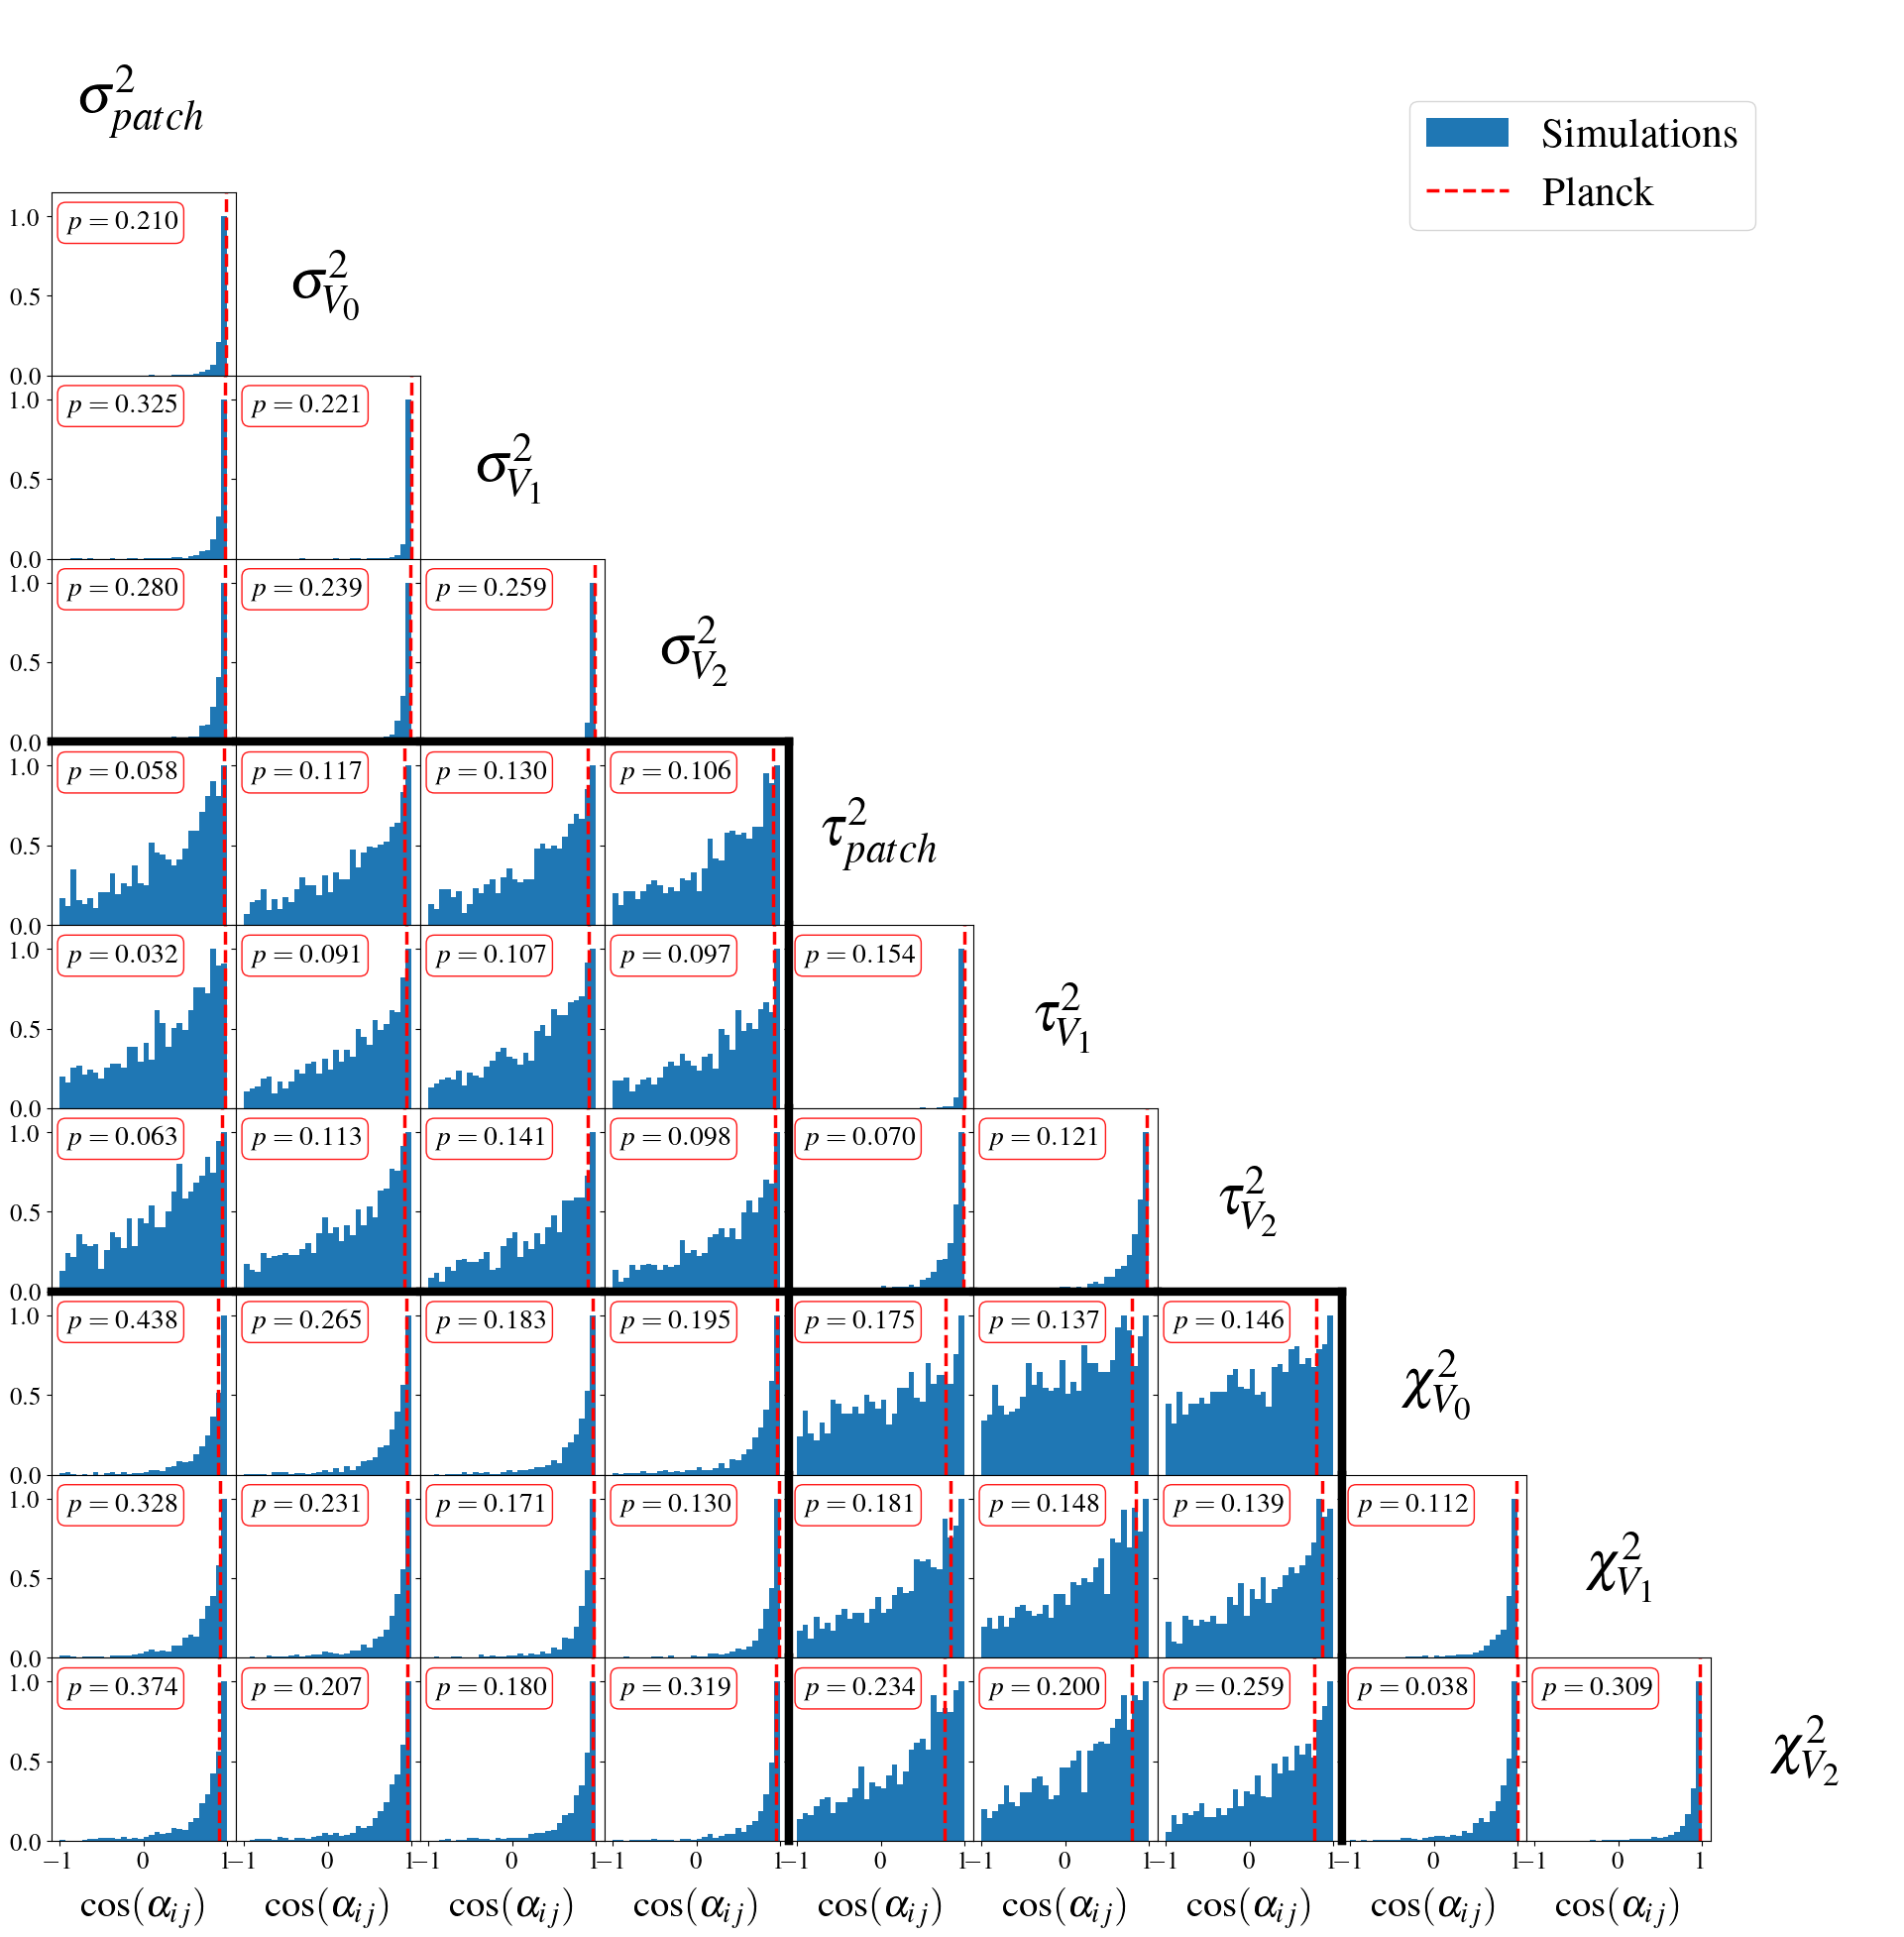

In [35]:
fig, ax = new_corner_cosine_histogram(sim_dips,planck_dips,my_labels=dip_labels,title='',group_sizes=[4,3,3])
#plt.show()

#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/massive_clustering_cornerplot.pdf', format='pdf', bbox_inches='tight', dpi=300)


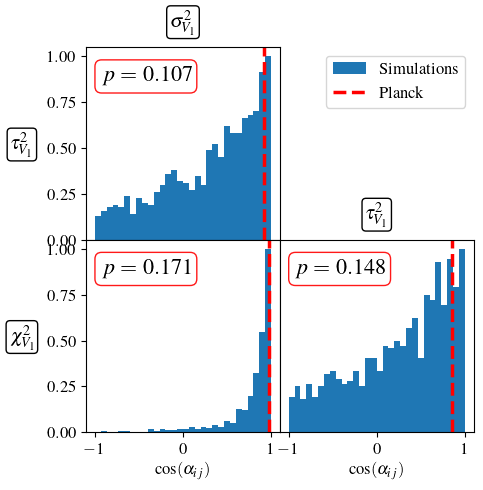

In [36]:
corner_cosine_histogram(dips_sigma_V1,dips_tau_V1,dips_gof_V1,
                        dip_planck_sigma_V1,dip_planck_tau_V1,dip_planck_gof_V1,
                        my_labels=[r'$\sigma^2_{V_1}$', r'$\tau^2_{V_1}$', r'$\chi^2_{V_1}$'],
                        title=r'')

if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/cosine_histogram_V1.pdf', format='pdf', bbox_inches='tight', dpi=300)

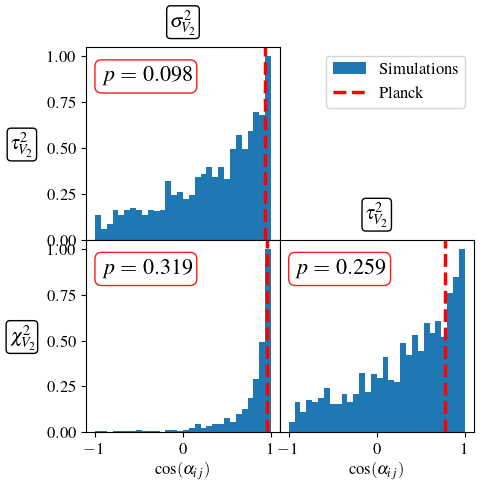

In [37]:
corner_cosine_histogram(dips_sigma_V2,dips_tau_V2,dips_gof_V2,
                        dip_planck_sigma_V2,dip_planck_tau_V2,dip_planck_gof_V2,
                        my_labels=[r'$\sigma^2_{V_2}$', r'$\tau^2_{V_2}$', r'$\chi^2_{V_2}$'],
                        title=r'')
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/cosine_histogram_V2.pdf', format='pdf', bbox_inches='tight', dpi=300)

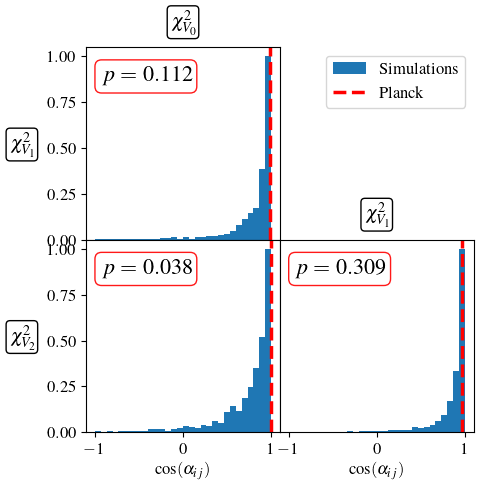

In [38]:
corner_cosine_histogram(dips_gof_V0,dips_gof_V1,dips_gof_V2,
                        dip_planck_gof_V0,dip_planck_gof_V1,dip_planck_gof_V2,
                        my_labels=[r'$\chi^2_{V_0}$', r'$\chi^2_{V_1}$', r'$\chi^2_{V_2}$'],
                        title=r'')
if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/cosine_histogram_V2.pdf', format='pdf', bbox_inches='tight', dpi=300)

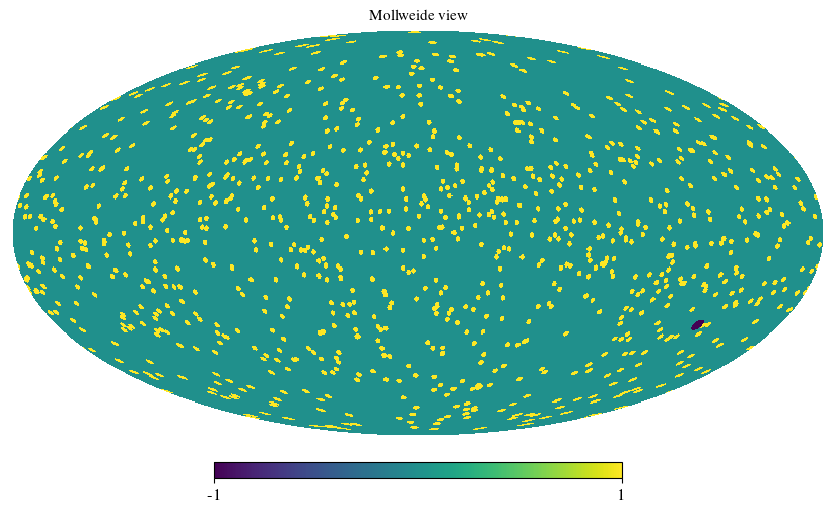

In [44]:
sky = np.zeros(12*2048**2)

for i in range(1000):
    if i !=970:
        plotmask = hp.query_disc(nside=2048, vec= dips_sigma_V0[i,:], radius = np.radians(1))
        sky[plotmask] = 1

mask_planck = hp.query_disc(nside=2048, vec= dip_planck_sigma_V0, radius = np.radians(2))

sky[mask_planck]=-1

hp.mollview(sky)


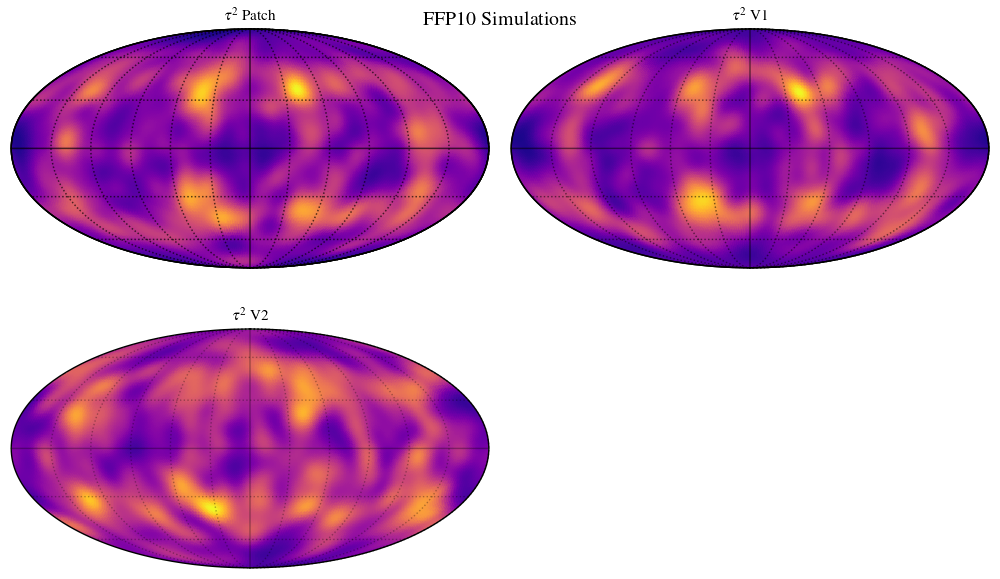

In [45]:
# dipole_sets = [dips_sigma_patch, dips_sigma_V0, dips_sigma_V1, dips_sigma_V2]
# titles = [r'$\sigma^2$ Patch', r'$\sigma^2$ V0', r'$\sigma^2$ V1', r'$\sigma^2$ V2']

dipole_sets = [dips_tau_patch, dips_tau_V1, dips_tau_V2]
titles = [r'$\tau^2$ Patch', r'$\tau^2$ V1', r'$\tau^2$ V2']

# dipole_sets = [dips_gof_V0, dips_gof_V1, dips_gof_V2]
# titles = [r'$\chi^2$ V0', r'$\chi^2$ V1', r'$\chi^2$ V2']

plt.figure(figsize=(10, 6)) 

subplot_indices = [221, 222, 223, 224]

for i in range(3):
    plot_dipole_density_subplot(
        dipole_vectors=dipole_sets[i], 
        sub_index=subplot_indices[i], 
        title=titles[i],
        nside=64, 
        fwhm_deg=15.0
    )

plt.subplots_adjust(wspace=0.0, hspace=0.0)

plt.suptitle('FFP10 Simulations')
plt.show()

<Figure size 1000x600 with 0 Axes>

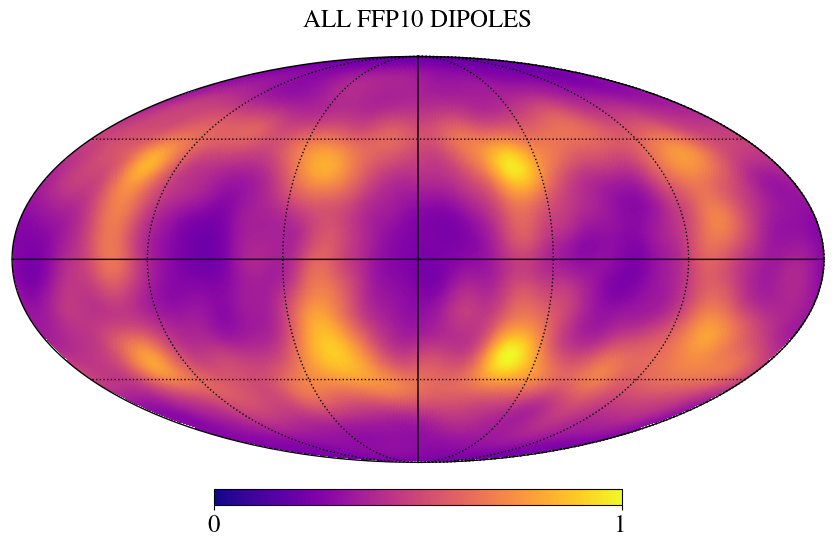

In [41]:
alldips = np.vstack((dips_sigma_patch,dips_sigma_V0,dips_sigma_V1,dips_sigma_V2,dips_tau_patch,dips_tau_V1,dips_tau_V2,dips_gof_V0,
                    dips_gof_V1,dips_gof_V2))

plot_dipole_density(alldips,title='ALL FFP10 DIPOLES')
#plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dipole_heatmap_all.pdf', format='pdf', bbox_inches='tight', dpi=300)

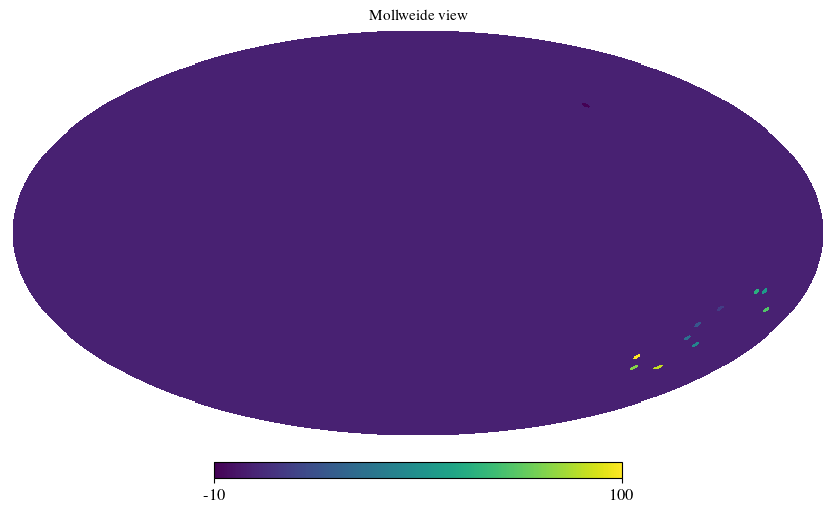

In [47]:
sky = np.zeros(12*2048**2)

for i, dip in enumerate(planck_dips):
    plotmask = hp.query_disc(nside=2048, vec= dip, radius = np.radians(1))
    sky[plotmask] = 10*i+10

l_deg = 264.021
b_deg = 48.253

theta = np.radians(90.0 - b_deg)
phi = np.radians(l_deg)

vec = hp.ang2vec(theta, phi)
kin_dip_mask = hp.query_disc(nside=2048, vec= vec, radius = np.radians(1))

sky[kin_dip_mask]=-10
hp.mollview(sky)


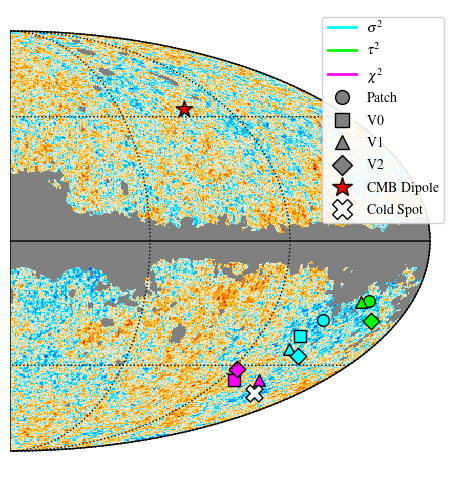

In [48]:
from matplotlib.colors import ListedColormap
m = hp.read_map("./maps/COM_CompMap_CMB-smica_2048_R1.20.fits")
m = hp.ud_grade(m, nside_out = 512)
m = hp.ma(m)
colombi1_cmap = ListedColormap(np.loadtxt("./utils/planck_color.txt")/255.)
colombi1_cmap.set_bad("gray") # color of missing pixels
colombi1_cmap.set_under("white") 

cmap = colombi1_cmap
dip_labels = [r'$\sigma^2_{patch}$', r'$\sigma^2_{V0}$', r'$\sigma^2_{V1}$', r'$\sigma^2_{V2}$',           
              r'$\tau^2_{patch}$',r'$\tau^2_{V1}$', r'$\tau^2_{V2}$',
              r'$\chi^2_{V0}$', r'$\chi^2_{V1}$', r'$\chi^2_{V2}$']

plt.figure(figsize=(8, 6))

m[~mask] = np.nan

hp.mollview((m),cmap = cmap,title="",cbar=False,hold=True)
hp.graticule(45, 60)

colors = ['cyan','cyan','cyan','cyan',
           'lime', 'lime','lime',
           'magenta','magenta','magenta'] 

markers = ['o', 's', '^', 'D',
           'o', '^', 'D',
           's', '^', 'D']

for i, dip in enumerate(planck_dips):
    c = colors[i]
    theta, phi = hp.vec2ang(np.array(dip))
    
    hp.projscatter(theta, phi, marker=markers[i], color=c, edgecolor='k', s=70)

l_deg = 264.021
b_deg = 48.253

theta_kin = np.radians(90.0 - b_deg)
phi_kin = np.radians(l_deg)

hp.projscatter(theta_kin, phi_kin, marker='*', color='red', edgecolor='black', s=150)

#The CS

l_cs = 208
b_cs = -56.5

theta_cold = np.radians(90.0-b_cs)
phi_cold = np.radians(l_cs)

hp.projscatter(
    theta_cold, phi_cold, 
    marker='X', 
    color='white',     
    edgecolor='black', 
    s=150
)

legend_elements = [
    Line2D([0], [0], color='cyan', lw=2, label=r'$\sigma^2$'),
    Line2D([0], [0], color='lime', lw=2, label=r'$\tau^2$'),
    Line2D([0], [0], color='magenta', lw=2, label=r'$\chi^2$'),
    
    # Spacer (optional, or just continue)
    
    # Group B: Shapes (Black/Gray markers to represent geometry)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=10, label='Patch'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=10, label='V0'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=10, label='V1'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=10, label='V2'),
    
    # Group C: CMB Dipole
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markeredgecolor='k', markersize=15, label='CMB Dipole'),
    # Group D: CMB Cold Spot
    Line2D([0], [0], marker='X', color='w', markerfacecolor='white', markeredgecolor='k', markersize=15, label='Cold Spot'),
]

# --- 4. Calculate Great Circle Points ---
# def get_great_circle_coords(normal_vec, num_points=1000000):
#     """
#     Returns (theta, phi) coordinates for the great circle 
#     defined by the normal vector 'normal_vec'.
#     """
#     # 1. Normalize the normal vector
#     n = normal_vec / np.linalg.norm(normal_vec)
    
#     # 2. Find orthogonal unit vectors (u, v)
#     a = np.array([1/np.sqrt(2), 0, 1/np.sqrt(2)])
#     if np.abs(np.dot(n, a)) > 0.99:
#         a = np.array([1, 0, 0])
        
#     u = np.cross(n, a)
#     u = u / np.linalg.norm(u)
    
#     v = np.cross(n, u)
#     v = v / np.linalg.norm(v)
    
#     # 3. Parametrize the circle
#     t = np.linspace(-1000, 1000, num_points)
    
#     # Shape becomes (3, num_points)
#     circle_vecs = np.outer(u, np.cos(t)) + np.outer(v, np.sin(t))
    
#     # 4. FIX: Pass the entire array as one argument
#     return hp.vec2ang(circle_vecs)

# # Get the vector for the Kinematic Dipole
# vec_kin = hp.ang2vec(theta_kin, phi_kin)

# # Get the coordinates for the line
# gc_theta, gc_phi = get_great_circle_coords(vec_kin)

# --- 5. Plot the Great Circle ---
# hp.projscatter(
#     gc_theta, 
#     gc_phi, 
#     c='red',            # Black line
#     marker='o',
#     s=2,     
#     alpha=1,        # Slight transparency
#     label='Orthogonal Plane',
#     linestyle='dashed',
#     lonlat=False
# )

# Important: Update legend to include the line
# We add a proxy artist (Line2D) for this black line
# from matplotlib.lines import Line2D
# legend_elements.append(
#     Line2D([0], [0], color='red', linestyle='-', lw=2, label='Orthogonal Plane')
# )

# Add the custom legend to the plot
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9, ncol=1,fontsize=10,labelspacing=0.7)
plt.xlim(0, 2.1) 
plt.ylim(-1.1, 1.1)

if SAVE_PLOT:
    plt.savefig(f'./new_figures/R{DISK_RADIUS}DR{int(100*DISK_PERCENTAGE_REQUIRED)}/dipole_directions_plot.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()
      